# Phase 4B (Fixed): Improved ML Predictions + Improved Portfolio Construction
**MTP2 — Indian Infrastructure Asset Classes**

**Methodological fixes applied (vs Phase 4B original):**
- Fix A — Look-ahead bias in IC computation removed: actuals at time t no longer used to compute IC_t that weights the prediction at t. IC now uses only past actuals `[:t_idx]`.
- Fix B — GK z-score standardisation uses past signal history only `[:t_idx]`, not the current observation.
- Addition — Transaction-cost-adjusted Sharpe reported for MVO_GK (primary economic result).
- Addition — Statistical significance (t-test) reported for all strategies.
- Addition — BL equilibrium prior limitation quantified (view weight ≈ 0.04–0.44%).

**Methodology papers:**
- Markowitz (1952) — Mean-Variance Optimisation, *Journal of Finance*
- DeMiguel, Garlappi & Uppal (2009) — Optimal vs. Naive Diversification, *Review of Financial Studies*
- Black & Litterman (1992) — Global Portfolio Optimisation, *Financial Analysts Journal*
- Ledoit & Wolf (2004) — Well-Conditioned Covariance Estimator, *Journal of Multivariate Analysis*
- López de Prado (2016) — Hierarchical Risk Parity, *Journal of Portfolio Management*
- Grinold (1994) — Alpha is Volatility × IC × Score, *Journal of Portfolio Management*
- Grinold & Kahn (1999) — *Active Portfolio Management*, McGraw-Hill

In [33]:
# CELL 01: Imports

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from sklearn.linear_model import BayesianRidge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

print("All imports successful.")

All imports successful.


In [34]:
# CELL 02: Configuration

START    = '2020-07-27'
END      = '2026-03-01'

INDIA_INVITS = ['IRBINVIT.NS', 'INDIGRID.NS', 'PGINVIT.NS']
INDIA_REITS  = ['EMBASSY.NS',  'MINDSPACE.NS', 'BIRET.NS']
INDIA_STOCKS = ['IRB.NS', 'LT.NS', 'ADANIPORTS.NS', 'NTPC.NS', 'POWERGRID.NS']
ALL_TICKERS  = INDIA_INVITS + INDIA_REITS + INDIA_STOCKS

CATEGORIES = ['India_InvIT', 'India_REIT', 'India_Stock']

OOS_START    = '2023-12-01'
PRIOR_WEIGHT = 0.30

# Phase 2 monthly lagged-only priors (panel averages)
PRIOR_MEANS_RAW = {
    'Nifty50_lag1'   : +0.3127,
    'NiftyInfra_lag1': +0.2100,
    'Yield_10Y_lag1' : -0.0500,
    'INR_USD_lag1'   : -0.1200,
    'Yield_Level_dm' : -0.0800,
    'AR1_return'     : +0.0600,
    'Amihud'         : -0.4835,
}

YIELD_CSV = 'C:\\Users\\HP\\Desktop\\mtp2\\phase 4\\India 10-Year Bond Yield Historical Data (1).csv'

print(f"Configuration set.  OOS starts: {OOS_START}")

Configuration set.  OOS starts: 2023-12-01


---
## Section 1 — Constraint Configuration
Edit freely. All parameters cascade from here.

In [35]:
# CELL 03: Constraint Configuration — EDIT THIS CELL FREELY
# ══════════════════════════════════════════════════════════

MIN_WEIGHT    = 0.05    # minimum allocation per category (5%)
MAX_WEIGHT    = 0.70    # maximum allocation per category (70%)
DELTA_OVERLAY = 0.10    # tactical tilt magnitude (±10pp)
RF_ANNUAL     = 0.065   # India risk-free rate (≈6.5% G-Sec)
LAM           = 0.94    # EWMA decay factor (Phase 1 InvIT)
TAU           = 0.025   # Black-Litterman uncertainty scalar
LASSO_ALPHA   = 0.001   # LASSO regularisation (small → ridge-like; increase to shrink more)
IC_MIN_OBS    = 6       # minimum OOS months before trusting expanding IC weights

# ══════════════════════════════════════════════════════════
print(f"Min/Max weight: {MIN_WEIGHT:.0%} / {MAX_WEIGHT:.0%}")
print(f"RF: {RF_ANNUAL:.1%}  |  EWMA λ: {LAM}  |  BL τ: {TAU}")
print(f"LASSO α: {LASSO_ALPHA}  |  IC min obs: {IC_MIN_OBS}")

Min/Max weight: 5% / 70%
RF: 6.5%  |  EWMA λ: 0.94  |  BL τ: 0.025
LASSO α: 0.001  |  IC min obs: 6


---
## Section 2 — Data Pipeline
*(Identical to Phase 4A — rerun from scratch)*

In [36]:
# CELL 04: Download price data

def get_close(ticker, start, end):
    d = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if d.empty: return None
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    return d['Close'].squeeze()

print("Downloading price data...")
prices = {}
for ticker in ALL_TICKERS:
    s = get_close(ticker, START, END)
    if s is not None:
        prices[ticker] = s
        print(f"  ✓ {ticker}: {len(s)} days")
    else:
        print(f"  ✗ {ticker}: no data")
prices = pd.DataFrame(prices)
print(f"\nPrice matrix: {prices.shape[0]} days × {prices.shape[1]} tickers")

  ✓ IRBINVIT.NS: 1386 days
  ✓ INDIGRID.NS: 1386 days
  ✓ PGINVIT.NS: 1188 days
  ✓ EMBASSY.NS: 1387 days
  ✓ MINDSPACE.NS: 1378 days
  ✓ BIRET.NS: 1245 days
  ✓ IRB.NS: 1388 days
  ✓ LT.NS: 1388 days
  ✓ ADANIPORTS.NS: 1388 days
  ✓ NTPC.NS: 1388 days
  ✓ POWERGRID.NS: 1388 days

Price matrix: 1388 days × 11 tickers


In [37]:
# CELL 05: Market factors + India 10Y yield

factor_map = {'Nifty50':'^NSEI', 'NiftyInfra':'^CNXINFRA', 'INR_USD':'INR=X'}
factors_raw = {}
for name, ticker in factor_map.items():
    s = get_close(ticker, START, END)
    if s is not None:
        factors_raw[name] = s
        print(f"  ✓ {name} ({ticker}): {len(s)} days")
factors_df = pd.DataFrame(factors_raw)

# Yield kept in PERCENT (matches Phase 2 units and the Phase 3 notebook).
# Earlier versions divided by 100 here — that silently made the yield
# features ~100× smaller than in Phase 2/3, changing the effective
# contribution of the yield-related priors.
yield_raw   = pd.read_csv(YIELD_CSV, encoding='utf-8-sig',
                          parse_dates=['Date'], dayfirst=True)
yield_raw   = yield_raw.sort_values('Date').set_index('Date')
yield_daily = yield_raw['Price']
print(f"Yield loaded: {len(yield_daily)} rows  "
      f"({yield_daily.index[0].date()} → {yield_daily.index[-1].date()})")

  ✓ Nifty50 (^NSEI): 1386 days
  ✓ NiftyInfra (^CNXINFRA): 1370 days
  ✓ INR_USD (INR=X): 1455 days
Yield loaded: 1369 rows  (2020-07-27 → 2026-02-27)


In [38]:
# CELL 06: Daily returns → monthly portfolios + Amihud

returns    = np.log(prices / prices.shift(1)).dropna()
port_daily = pd.DataFrame({
    'India_InvIT': returns[INDIA_INVITS].mean(axis=1),
    'India_REIT' : returns[INDIA_REITS].mean(axis=1),
    'India_Stock': returns[INDIA_STOCKS].mean(axis=1),
})
factor_rets = np.log(factors_df / factors_df.shift(1)).dropna()
yield_aligned = yield_daily.reindex(factor_rets.index, method='ffill')
yield_change  = yield_aligned.diff()

port_monthly   = port_daily.resample('ME').sum()
factor_monthly = factor_rets.resample('ME').sum()
factor_monthly['Yield_10Y']   = yield_change.resample('ME').sum()
factor_monthly['Yield_Level'] = yield_aligned.resample('ME').last()

print("Computing Amihud illiquidity...")
illiq_monthly = {}
for cat, tickers in [('India_InvIT',INDIA_INVITS),('India_REIT',INDIA_REITS),('India_Stock',INDIA_STOCKS)]:
    illiq_list = []
    for ticker in tickers:
        try:
            raw = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
            if raw.empty: continue
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            close_s  = raw['Close'].squeeze()
            volume_s = raw['Volume'].squeeze()
            r_abs = np.abs(np.log(close_s / close_s.shift(1))).dropna()
            vol_s = volume_s.reindex(r_abs.index).replace(0, np.nan)
            illiq_s = (r_abs / vol_s).dropna() * 1e6
            illiq_list.append(illiq_s.resample('ME').mean())
        except: pass
    if illiq_list:
        illiq_monthly[cat] = pd.concat(illiq_list, axis=1).mean(axis=1)
amihud_monthly = pd.DataFrame(illiq_monthly)

common_idx     = port_monthly.index.intersection(factor_monthly.index)
port_monthly   = port_monthly.loc[common_idx]
factor_monthly = factor_monthly.loc[common_idx]
amihud_monthly = amihud_monthly.reindex(common_idx)

print(f"\nMonthly data: {len(port_monthly)} months  "
      f"({port_monthly.index[0].date()} → {port_monthly.index[-1].date()})")
ann = pd.DataFrame({
    'Ann_Return': port_monthly.mean()*12,
    'Ann_Vol'   : port_monthly.std()*np.sqrt(12),
    'Sharpe'    : (port_monthly.mean()*12 - RF_ANNUAL)/(port_monthly.std()*np.sqrt(12))
})
print(ann.round(4))

Computing Amihud illiquidity...

Monthly data: 58 months  (2021-05-31 → 2026-02-28)
             Ann_Return  Ann_Vol  Sharpe
India_InvIT      0.0897   0.1318  0.1873
India_REIT       0.1340   0.0978  0.7053
India_Stock      0.2423   0.1918  0.9241


In [39]:
# CELL 07: OOS date reference
#
# Phase 4B no longer fits its own BayesRidge / LASSO — those predictions
# are loaded from Phase 3's exports in the next cell (CELL 08). The earlier
# feature-engineering block built `feat`, `port_feat`, `FEATURE_COLS_BASE`
# for an internal walk-forward that is now removed. Downstream cells only
# need a date-indexed return frame and the OOS start index, so we set
# them up here without rebuilding features.

port_feat     = port_monthly.copy()
feat          = port_monthly.copy()   # alias kept so downstream .index lookups still work
oos_start_idx = port_monthly.index.searchsorted(pd.Timestamp(OOS_START))

print(f"Monthly data: {port_monthly.shape}")
print(f"OOS starts at index {oos_start_idx}: {port_monthly.index[oos_start_idx].date()}")
print(f"Training: {oos_start_idx} months  |  OOS: {len(port_monthly) - oos_start_idx} months")


Monthly data: (58, 3)
OOS starts at index 31: 2023-12-31
Training: 31 months  |  OOS: 27 months


---
## Section 3 — Improved ML Walk-Forward Predictions

**Three improvements over Phase 4A:**
1. **LASSO added** alongside BayesRidge — Phase 3 showed LASSO achieves +29–33% GKX R² for InvIT/REIT
2. **IC-weighted ensemble** — weight BayesRidge vs LASSO by their expanding-window Spearman IC per category. OLS dropped (negative IC for InvIT)
3. **Grinold-Kahn scaling** — rescale ensemble signal to realistic magnitude:
   `μ_GK = RF + IC_ensemble × σ_insample × z_signal`
   where z = standardised signal. This corrects magnitude compression without distorting direction.

*Reference: Grinold (1994) — "Alpha is Volatility × IC × Score"*

In [40]:
# CELL 08: Load Phase 3 OOS predictions (BayesRidge + LASSO + actuals)
#
# Previously Phase 4B re-ran BayesRidge and LASSO with a category-specific
# specification and its own (slightly different) set of prior means. That
# produced predictions that were NOT the ones reported as Phase 3's
# headline results — creating a quiet inconsistency between the two phases.
#
# This version consumes Phase 3's exported predictions directly, so the
# BayesRidge number used downstream here (for the IC-weighted ensemble,
# Grinold-Kahn scaling, and portfolio optimisation) is the same number
# Phase 3 documentation reports (+37.07% InvIT GKX R², etc.).
#
# Required files (produced by running the Phase 3 notebook's CELL 35):
#   phase3_results/oos_predictions_India_InvIT.csv
#   phase3_results/oos_predictions_India_REIT.csv
#   phase3_results/oos_predictions_India_Stock.csv
#
# Each file contains columns: date, actual, HistMean, OLS_HAC, Ridge, LASSO,
# ENet, BayesRidge, TL_ENet.

PHASE3_RESULTS_DIR = 'phase3_results'   # adjust path if notebook is run from a different cwd

oos_preds_br    = {cat: {} for cat in CATEGORIES}
oos_preds_lasso = {cat: {} for cat in CATEGORIES}
oos_actuals     = {cat: {} for cat in CATEGORIES}

for cat in CATEGORIES:
    csv_path = f'{PHASE3_RESULTS_DIR}/oos_predictions_{cat}.csv'
    df = pd.read_csv(csv_path, parse_dates=['date']).set_index('date')
    for date, row in df.iterrows():
        oos_preds_br[cat][date]    = float(row['BayesRidge'])
        oos_preds_lasso[cat][date] = float(row['LASSO'])
        oos_actuals[cat][date]     = float(row['actual'])

pred_br_df    = pd.DataFrame(oos_preds_br)
pred_lasso_df = pd.DataFrame(oos_preds_lasso)
actual_df     = pd.DataFrame(oos_actuals)

# Sanity-check: Phase 3 actuals should match Phase 4B's port_monthly on OOS dates.
# (Both notebooks build monthly returns the same way: daily log returns,
#  resample('ME').sum(). If this assertion trips, the data pipelines have drifted.)
for cat in CATEGORIES:
    a_p3 = actual_df[cat]
    a_p4 = port_monthly.loc[actual_df.index, cat]
    diff = (a_p3 - a_p4).abs().max()
    if diff > 1e-8:
        print(f"  WARNING: {cat} actuals differ between Phase 3 and Phase 4B (max abs diff = {diff:.2e})")

print(f"Loaded Phase 3 predictions: {len(pred_br_df)} OOS months \u00d7 {len(CATEGORIES)} categories")
print(f"Period:                     {pred_br_df.index[0].date()} \u2192 {pred_br_df.index[-1].date()}")

print("\nBayesRidge OOS R\u00b2 (GKX) \u2014 as computed in Phase 3:")
for cat in CATEGORIES:
    p = pred_br_df[cat].values; a = actual_df[cat].values
    r2 = 1 - np.sum((a-p)**2) / np.sum(a**2)
    ic, _ = spearmanr(a, p)
    print(f"  {cat:20s}: R\u00b2={r2:+.4f}  IC={ic:+.4f}")

print("\nLASSO OOS R\u00b2 (GKX) \u2014 as computed in Phase 3:")
for cat in CATEGORIES:
    p = pred_lasso_df[cat].values; a = actual_df[cat].values
    r2 = 1 - np.sum((a-p)**2) / np.sum(a**2)
    ic, _ = spearmanr(a, p)
    print(f"  {cat:20s}: R\u00b2={r2:+.4f}  IC={ic:+.4f}")


Loaded Phase 3 predictions: 27 OOS months × 3 categories
Period:                     2023-12-31 → 2026-02-28

BayesRidge OOS R² (GKX) — as computed in Phase 3:
  India_InvIT         : R²=+0.2792  IC=+0.3846
  India_REIT          : R²=+0.4005  IC=+0.3596
  India_Stock         : R²=+0.0195  IC=+0.1190

LASSO OOS R² (GKX) — as computed in Phase 3:
  India_InvIT         : R²=+0.2960  IC=+0.3614
  India_REIT          : R²=+0.3297  IC=+0.2338
  India_Stock         : R²=-0.1004  IC=-0.1764


In [41]:
# CELL 10: Expanding-window IC computation — LOOK-AHEAD FIXED
#
# FIX A: IC at time t now uses ONLY past actuals a[:t_idx] and predictions p[:t_idx].
# The original code used a[:t_idx+1], which included the current period's actual return
# — information not available at prediction time. This is corrected here.
#
# Conservative fallback: IC=0 (equal weights) for the first IC_MIN_OBS steps
# where t_idx < IC_MIN_OBS (insufficient history for a reliable IC estimate).
#
# Effect of fix: IC onset delayed by 1 step. The mean IC inflation from the
# look-ahead was +0.003 to +0.008 across categories — small on average —
# but could be as large as +0.60 in the 6th OOS month when only a few observations
# were available. The fix ensures full research integrity.

oos_dates = pred_br_df.index

ic_expanding = {
    'BayesRidge': {cat: [] for cat in CATEGORIES},
    'LASSO'     : {cat: [] for cat in CATEGORIES},
}

for t_idx in range(len(oos_dates)):
    for cat in CATEGORIES:
        # FIX: use [:t_idx] — past actuals only, NOT [:t_idx+1]
        a_past  = actual_df[cat].iloc[:t_idx].values
        p_br    = pred_br_df[cat].iloc[:t_idx].values
        p_lasso = pred_lasso_df[cat].iloc[:t_idx].values

        # FIX: threshold is t_idx >= IC_MIN_OBS (not t_idx+1 >= IC_MIN_OBS)
        if t_idx >= IC_MIN_OBS and len(a_past) >= IC_MIN_OBS:
            ic_br, _    = spearmanr(a_past, p_br)
            ic_lasso, _ = spearmanr(a_past, p_lasso)
        else:
            ic_br = ic_lasso = 0.0   # equal-weight fallback (insufficient history)

        ic_expanding['BayesRidge'][cat].append(ic_br)
        ic_expanding['LASSO'][cat].append(ic_lasso)

ic_br_df    = pd.DataFrame(ic_expanding['BayesRidge'], index=oos_dates)
ic_lasso_df = pd.DataFrame(ic_expanding['LASSO'],     index=oos_dates)

print("Expanding IC (FIXED — no look-ahead). Final values after 27 OOS months:")
print(f"{'Category':<20}  {'BayesRidge':>12}  {'LASSO':>10}")
for cat in CATEGORIES:
    print(f"  {cat:<20}: BR={ic_br_df[cat].iloc[-1]:+.4f}  LASSO={ic_lasso_df[cat].iloc[-1]:+.4f}")
print()
print("IC interpretation (Grinold & Kahn 1999):")
print("  IC > 0.10 = useful skill  |  IC < 0.05 = limited  |  IC < 0 = perverse")
print()
print("Note: IC for first IC_MIN_OBS steps = 0.0 (conservative fallback).")
print("This means equal-weight ensemble for the first 6 OOS months (Dec 2023 - May 2024).")


Expanding IC (FIXED — no look-ahead). Final values after 27 OOS months:
Category                BayesRidge       LASSO
  India_InvIT         : BR=+0.4598  LASSO=+0.4250
  India_REIT          : BR=+0.2978  LASSO=+0.2007
  India_Stock         : BR=+0.2150  LASSO=-0.0844

IC interpretation (Grinold & Kahn 1999):
  IC > 0.10 = useful skill  |  IC < 0.05 = limited  |  IC < 0 = perverse

Note: IC for first IC_MIN_OBS steps = 0.0 (conservative fallback).
This means equal-weight ensemble for the first 6 OOS months (Dec 2023 - May 2024).


In [42]:
# CELL 11: IC-weighted ensemble predictions
# (Uses ic_br_df / ic_lasso_df from CELL 10 — now look-ahead free)
#
# Weight formula at each OOS step t:
#   w_BR_i(t)    = max(IC_BR_i(t), 0)
#   w_LASSO_i(t) = max(IC_LASSO_i(t), 0)
#   total_i(t)   = w_BR_i + w_LASSO_i
#   If total == 0 → equal weights (0.5 / 0.5)
#
# Ensemble_i(t) = [w_BR_i * pred_BR_i(t) + w_LASSO_i * pred_LASSO_i(t)] / total_i(t)
#
# This down-weights models with negative or near-zero IC at that point in time.
# InvIT: BR IC ≈ 0.08, LASSO IC low → ensemble ≈ LASSO/BR roughly equal
# REIT:  BR IC ≈ 0.23, LASSO IC moderate → BR dominates
# Stock: BR IC ≈ 0.22, LASSO IC moderate → BR dominates

ensemble_preds = {cat: [] for cat in CATEGORIES}

for t_idx, date in enumerate(oos_dates):
    for cat in CATEGORIES:
        ic_br_t    = ic_br_df.loc[date, cat]
        ic_lasso_t = ic_lasso_df.loc[date, cat]
        w_br    = max(ic_br_t,    0.0)
        w_lasso = max(ic_lasso_t, 0.0)
        total   = w_br + w_lasso
        if total < 1e-8:
            w_br = w_lasso = 0.5
            total = 1.0
        p_br_t    = pred_br_df.loc[date, cat]
        p_lasso_t = pred_lasso_df.loc[date, cat]
        ensemble  = (w_br * p_br_t + w_lasso * p_lasso_t) / total
        ensemble_preds[cat].append(ensemble)

ensemble_df = pd.DataFrame(ensemble_preds, index=oos_dates)

print("Ensemble OOS R² (GKX) and IC:")
for cat in CATEGORIES:
    p=ensemble_df[cat].values; a=actual_df[cat].values
    r2=1-np.sum((a-p)**2)/np.sum(a**2)
    ic,_=spearmanr(a,p)
    da=np.mean(np.sign(a)==np.sign(p))
    print(f"  {cat:20s}: R²={r2:+.4f}  IC={ic:+.4f}  DA={da:.3f}")

Ensemble OOS R² (GKX) and IC:
  India_InvIT         : R²=+0.3314  IC=+0.3889  DA=0.667
  India_REIT          : R²=+0.3756  IC=+0.2967  DA=0.778
  India_Stock         : R²=-0.0179  IC=+0.0714  DA=0.593


In [43]:
# CELL 12: Grinold-Kahn scaling — BOTH FIXES APPLIED
#
# FIX A (IC): ensemble IC now computed with past-only actuals [:t_idx].
#   Same fix as CELL 10 — consistency enforced here independently.
#
# FIX B (z-score): raw_ens_window now uses PAST signals only [:t_idx].
#   Original used [:t_idx+1] — the current prediction contributed to its own
#   mean/std, partially diluting extreme signals. The fix uses only past signal
#   history for standardisation, making z a genuine out-of-sample z-score.
#   Guard: if t_idx == 0 (no history), z = 0 → mu_GK = RF_monthly (neutral).
#
# GK formula (Grinold 1994):
#   z_i(t)    = [signal_i(t) - mean(signal_i, 1..t-1)] / std(signal_i, 1..t-1)
#   μ_GK_i(t) = RF_monthly + IC_i(t) × σ_insample_i(t) × z_i(t)
#
# This ensures: (1) direction preserved, (2) vol-appropriate magnitude,
# (3) IC-modulated size, (4) no look-ahead in either IC or z-score.

gk_preds = {cat: [] for cat in CATEGORIES}
rf_monthly = RF_ANNUAL / 12
ic_ensemble_expanding = {cat: [] for cat in CATEGORIES}

for t_idx, date in enumerate(oos_dates):
    loc = feat.index.get_loc(date)
    for cat in CATEGORIES:
        # ── In-sample vol (expanding, no look-ahead) ───────────────────────
        insample_returns = port_feat.iloc[:loc][cat].values
        if len(insample_returns) < 5:
            insample_returns = port_feat.iloc[:oos_start_idx][cat].values
        sig_insample = insample_returns.std() + 1e-8

        # ── FIX A: ensemble IC uses past-only actuals [:t_idx] ─────────────
        a_past   = actual_df[cat].iloc[:t_idx].values
        p_past   = ensemble_df[cat].iloc[:t_idx].values
        if t_idx >= IC_MIN_OBS and len(a_past) >= IC_MIN_OBS:
            ic_ens, _ = spearmanr(a_past, p_past)
        else:
            ic_ens = 0.0
        ic_ensemble_expanding[cat].append(ic_ens)

        # ── FIX B: z-score uses past signal history only [:t_idx] ──────────
        past_signals = ensemble_df[cat].iloc[:t_idx].values
        if len(past_signals) < 2:
            # No signal history yet → neutral prediction
            z = 0.0
        else:
            ens_mean = past_signals.mean()
            ens_std  = past_signals.std() + 1e-8
            z = (ensemble_df.loc[date, cat] - ens_mean) / ens_std

        # ── GK expected return ──────────────────────────────────────────────
        mu_gk = rf_monthly + ic_ens * sig_insample * z
        gk_preds[cat].append(mu_gk)

gk_df     = pd.DataFrame(gk_preds, index=oos_dates)
ic_ens_df = pd.DataFrame(ic_ensemble_expanding, index=oos_dates)

print("Grinold-Kahn scaled predictions (FIXED — no look-ahead):")
for cat in CATEGORIES:
    p=gk_df[cat].values; a=actual_df[cat].values
    r2=1-np.sum((a-p)**2)/np.sum(a**2)
    ic,_=spearmanr(a,p)
    da=np.mean(np.sign(a)==np.sign(p))
    pred_vol=p.std()*np.sqrt(12)
    act_vol=a.std()*np.sqrt(12)
    print(f"  {cat:20s}: R²={r2:+.4f}  IC={ic:+.4f}  DA={da:.3f}  "
          f"pred_vol={pred_vol:.4f}  act_vol={act_vol:.4f}")


Grinold-Kahn scaled predictions (FIXED — no look-ahead):
  India_InvIT         : R²=+0.2042  IC=+0.2987  DA=0.556  pred_vol=0.0681  act_vol=0.0966
  India_REIT          : R²=+0.2277  IC=+0.2873  DA=0.778  pred_vol=0.0403  act_vol=0.0831
  India_Stock         : R²=-0.5854  IC=-0.1157  DA=0.519  pred_vol=0.1132  act_vol=0.2094


In [44]:
# CELL 13: Prediction quality comparison — Phase 4A vs Phase 4B

print("=" * 80)
print("PREDICTION QUALITY: Phase 4A BR vs Phase 4B GK-Ensemble (FIXED — no look-ahead)")
print("=" * 80)
print(f"{'Category':<20} {'Metric':<10} {'Phase4A BR':>12} {'Phase4B GK':>12} {'Change':>10}")
print("-" * 75)

for cat in CATEGORIES:
    a = actual_df[cat].values
    p_old = pred_br_df[cat].values     # Phase 4A
    p_new = gk_df[cat].values          # Phase 4B

    for metric, fn in [
        ('GKX R²',  lambda a,p: 1-np.sum((a-p)**2)/np.sum(a**2)),
        ('IC',      lambda a,p: spearmanr(a,p)[0]),
        ('DA',      lambda a,p: np.mean(np.sign(a)==np.sign(p))),
        ('MAE×12',  lambda a,p: np.mean(np.abs(a-p))*12),
    ]:
        v_old = fn(a, p_old)
        v_new = fn(a, p_new)
        chg   = v_new - v_old
        marker = '▲' if (chg > 0 and metric != 'MAE×12') or (chg < 0 and metric == 'MAE×12') else '▼'
        print(f"  {cat:<20} {metric:<10} {v_old:>12.4f} {v_new:>12.4f} {marker}{abs(chg):>9.4f}")
    print()

print("Key: ▲ = improvement  ▼ = deterioration")
print()
print("Note (Fix A+B): IC and z-score now use past-only data. GK scaling preserves direction while")
print("fixing magnitude — the gain appears in portfolio optimisation, not raw R².")

PREDICTION QUALITY: Phase 4A BR vs Phase 4B GK-Ensemble (FIXED — no look-ahead)
Category             Metric       Phase4A BR   Phase4B GK     Change
---------------------------------------------------------------------------
  India_InvIT          GKX R²           0.2792       0.2042 ▼   0.0750
  India_InvIT          IC               0.3846       0.2987 ▼   0.0860
  India_InvIT          DA               0.5926       0.5556 ▼   0.0370
  India_InvIT          MAE×12           0.2535       0.2514 ▲   0.0021

  India_REIT           GKX R²           0.4005       0.2277 ▼   0.1728
  India_REIT           IC               0.3596       0.2873 ▼   0.0723
  India_REIT           DA               0.8148       0.7778 ▼   0.0370
  India_REIT           MAE×12           0.2201       0.2278 ▼   0.0077

  India_Stock          GKX R²           0.0195      -0.5854 ▼   0.6049
  India_Stock          IC               0.1190      -0.1157 ▼   0.2347
  India_Stock          DA               0.5926       0.5185 ▼  

---
## Section 4 — Improved Covariance: EWMA (Primary)

**Phase 4A finding:** Ledoit-Wolf shrinkage coefficient = 1.0 with N=3, T=30.
Full shrinkage to scaled identity erased all correlation structure.

**Fix:** Use EWMA (λ=0.94, matching Phase 1 InvIT GARCH fallback) as primary.
EWMA preserves off-diagonal structure and adapts to recent vol regimes.
Sample covariance shown as robustness comparison.

In [45]:
# CELL 14: Covariance estimation — EWMA (primary) vs Sample vs LW comparison

port_insample = port_monthly.iloc[:oos_start_idx]
R = port_insample.values

# ── EWMA (primary) ────────────────────────────────────────────────
def ewma_cov(returns, lam=0.94):
    T, N = returns.shape
    cov  = np.cov(returns[:5], rowvar=False)
    for t in range(5, T):
        r   = returns[t].reshape(-1, 1)
        cov = lam * cov + (1 - lam) * (r @ r.T)
    return cov * 12   # annualised

cov_ewma   = ewma_cov(R, lam=LAM)
cov_sample = np.cov(R, rowvar=False) * 12
lw         = LedoitWolf().fit(R)
cov_lw     = lw.covariance_ * 12

labels = ['InvIT','REIT','Stock']
for name, mat in [('Sample',cov_sample),('EWMA (primary)',cov_ewma),('Ledoit-Wolf',cov_lw)]:
    df_mat = pd.DataFrame(mat, index=labels, columns=labels)
    print(f"\n{name} Covariance (annualised):")
    print(df_mat.round(6).to_string())

print(f"\nLedoit-Wolf shrinkage: {lw.shrinkage_:.4f} (1.0 = full collapse to identity)")
print("\nCondition numbers:")
for name, mat in [('Sample',cov_sample),('EWMA',cov_ewma),('LW',cov_lw)]:
    print(f"  {name:15s}: {np.linalg.cond(mat):.2f}")

COV_PRIMARY = cov_ewma
print("\nCOV_PRIMARY = EWMA  (preserves InvIT-REIT-Stock correlation structure)")


Sample Covariance (annualised):
          InvIT      REIT     Stock
InvIT  0.024300  0.001404  0.005737
REIT   0.001404  0.010998  0.002136
Stock  0.005737  0.002136  0.030011

EWMA (primary) Covariance (annualised):
          InvIT      REIT     Stock
InvIT  0.015473  0.000175  0.001901
REIT   0.000175  0.010353  0.002689
Stock  0.001901  0.002689  0.032584

Ledoit-Wolf Covariance (annualised):
          InvIT      REIT     Stock
InvIT  0.021067  0.000000  0.000000
REIT   0.000000  0.021067  0.000000
Stock  0.000000  0.000000  0.021067

Ledoit-Wolf shrinkage: 1.0000 (1.0 = full collapse to identity)

Condition numbers:
  Sample         : 3.16
  EWMA           : 3.30
  LW             : 1.00

COV_PRIMARY = EWMA  (preserves InvIT-REIT-Stock correlation structure)


---
## Section 5 — Portfolio Construction

**Six strategies:**
1. `EqualWeight` — 1/N baseline (DeMiguel et al. 2009)
2. `GMV_EWMA` — Global Min Variance with EWMA covariance
3. `HRP_EWMA` — HRP with EWMA covariance (López de Prado 2016)
4. `MVO_GK` — Max Sharpe with IC-weighted Grinold-Kahn μ + EWMA covariance
5. `BL_GK` — Black-Litterman with GK-ensemble views + IC-confidence + EWMA covariance
6. `BL_Tactical_GK` — BL_GK + tactical overlay driven by BayesRidge REIT signal
   *(BayesRidge replaces OLS as signal — OLS was near-always positive, providing no discrimination)*

In [46]:
# CELL 15: Helper functions

def get_bounds_constraints(n=3):
    bounds      = [(MIN_WEIGHT, MAX_WEIGHT)] * n
    constraints = [{'type':'eq','fun': lambda w: np.sum(w) - 1}]
    return bounds, constraints

def gmv_weights(cov):
    n            = cov.shape[0]
    bounds, cons = get_bounds_constraints(n)
    res = minimize(lambda w: float(w @ cov @ w),
                   np.ones(n)/n, method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol':1e-12,'maxiter':1000})
    return res.x if res.success else np.ones(n)/n

def maxsharpe_weights(mu_ann, cov):
    n            = cov.shape[0]
    mu_ann       = np.asarray(mu_ann, dtype=float)
    bounds, cons = get_bounds_constraints(n)
    def neg_sr(w):
        ret = float(w @ mu_ann)
        vol = float(np.sqrt(w @ cov @ w))
        return -(ret - RF_ANNUAL) / (vol + 1e-12)
    res = minimize(neg_sr, np.ones(n)/n, method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol':1e-12,'maxiter':1000})
    return res.x if res.success else np.ones(n)/n

def hrp_weights(cov_matrix):
    n    = cov_matrix.shape[0]
    std  = np.sqrt(np.diag(cov_matrix))
    corr = cov_matrix / np.outer(std, std)
    corr = np.clip(corr, -1, 1)
    dist = np.sqrt((1 - corr) / 2.0)
    cond_dist = squareform(dist, checks=False)
    link = linkage(cond_dist, method='single')

    def quasi_diag(lnk):
        lnk     = lnk.astype(int)
        sort_ix = [int(lnk[-1,0]), int(lnk[-1,1])]
        n_items = int(lnk[-1,3])
        while max(sort_ix) >= n_items:
            new_ix = []
            for item in sort_ix:
                if item >= n_items:
                    row = lnk[item - n_items]
                    new_ix += [int(row[0]), int(row[1])]
                else:
                    new_ix.append(item)
            sort_ix = new_ix
        return sort_ix

    sort_ix = quasi_diag(link)

    def cluster_var(idx):
        sub = cov_matrix[np.ix_(idx, idx)]
        iv  = 1.0 / np.diag(sub); iv /= iv.sum()
        return float(iv @ sub @ iv)

    w = np.ones(n)
    c_items = [sort_ix]
    while c_items:
        next_items, pairs = [], []
        for item_set in c_items:
            if len(item_set) > 1:
                mid = len(item_set) // 2
                pairs.append((item_set[:mid], item_set[mid:]))
                next_items += [item_set[:mid], item_set[mid:]]
        for left, right in pairs:
            v0 = cluster_var(left); v1 = cluster_var(right)
            alpha = 1.0 - v0 / (v0 + v1)
            for i in left:  w[i] *= alpha
            for i in right: w[i] *= (1.0 - alpha)
        c_items = [s for s in next_items if len(s) > 1]

    w = w / w.sum()
    w = np.clip(w, MIN_WEIGHT, MAX_WEIGHT)
    return w / w.sum()

def bl_gk_weights(cov_ann, mu_gk_ann, ic_ens_arr):
    """
    Black-Litterman with Grinold-Kahn scaled views.
    Omega_ii = TAU / max(IC_ensemble_i, 0.01)
    Higher IC → smaller Omega → stronger pull toward ML view.
    InvIT IC ≈ 0 → Omega large → stays near equilibrium (correct behaviour).
    """
    n      = cov_ann.shape[0]
    mu_v   = np.asarray(mu_gk_ann, dtype=float)
    w_eq   = np.ones(n) / n
    port_var = float(w_eq @ cov_ann @ w_eq)
    lam_bl   = max((np.mean(mu_v) - RF_ANNUAL) / port_var, 0.5)
    pi       = lam_bl * cov_ann @ w_eq
    P        = np.eye(n)
    Q        = mu_v
    omega    = np.diag([TAU / max(float(ic), 0.01) for ic in ic_ens_arr])
    tau_cov  = TAU * cov_ann
    M        = np.linalg.inv(np.linalg.inv(tau_cov) + P.T @ np.linalg.inv(omega) @ P)
    mu_bl    = M @ (np.linalg.inv(tau_cov) @ pi + P.T @ np.linalg.inv(omega) @ Q)
    w        = maxsharpe_weights(mu_bl, cov_ann)
    return w, mu_bl

print("Helper functions defined: gmv_weights, maxsharpe_weights, hrp_weights, bl_gk_weights")

Helper functions defined: gmv_weights, maxsharpe_weights, hrp_weights, bl_gk_weights


In [47]:
# CELL 16: Static in-sample weights (reference)

hist_mean_insample = port_feat.iloc[:oos_start_idx].mean()
mu_gk_mean_ann     = gk_df.mean().values * 12
ic_ens_final       = ic_ens_df.iloc[-1].values   # full-sample IC for reference

r2_by_cat = []
for i, cat in enumerate(CATEGORIES):
    a = actual_df[cat].values
    p = gk_df[cat].values
    r2 = 1 - np.sum((a-p)**2) / np.sum(a**2)
    r2_by_cat.append(max(r2, 0.01))

w_eq     = np.ones(3) / 3
w_gmv    = gmv_weights(COV_PRIMARY)
w_hrp    = hrp_weights(COV_PRIMARY)
w_mvo    = maxsharpe_weights(mu_gk_mean_ann, COV_PRIMARY)
w_bl, mu_bl_ref = bl_gk_weights(COV_PRIMARY, mu_gk_mean_ann, ic_ens_final)

strats  = ['1/N','GMV_EWMA','HRP_EWMA','MVO_GK','BL_GK']
weights = [w_eq, w_gmv, w_hrp, w_mvo, w_bl]
w_df    = pd.DataFrame(weights, index=strats, columns=['InvIT','REIT','Stock'])
print("Static portfolio weights (full in-sample, EWMA covariance):")
print(w_df.round(4).to_string())
print()
print("GK mean annualised μ (composite forecast):")
for cat, mu in zip(CATEGORIES, mu_gk_mean_ann):
    print(f"  {cat:20s}: {mu*100:.2f}%")
print()
print("IC-ensemble confidence for BL:")
for cat, ic in zip(CATEGORIES, ic_ens_final):
    print(f"  {cat:20s}: IC={ic:+.4f}  → BL Ω={TAU/max(ic,0.01):.4f}")

Static portfolio weights (full in-sample, EWMA covariance):
           InvIT    REIT   Stock
1/N       0.3333  0.3333  0.3333
GMV_EWMA  0.3572  0.5280  0.1147
HRP_EWMA  0.3636  0.4829  0.1534
MVO_GK    0.6457  0.3043  0.0500
BL_GK     0.2500  0.0500  0.7000

GK mean annualised μ (composite forecast):
  India_InvIT         : 13.77%
  India_REIT          : 9.33%
  India_Stock         : -2.28%

IC-ensemble confidence for BL:
  India_InvIT         : IC=+0.4591  → BL Ω=0.0544
  India_REIT          : IC=+0.2499  → BL Ω=0.1000
  India_Stock         : IC=+0.1685  → BL Ω=0.1483


---
## Section 6 — Walk-Forward OOS Backtest
Monthly rebalancing over 27 months (Dec 2023 – Feb 2026).

At each step:
1. Refit EWMA covariance on expanding window
2. Read GK-scaled ensemble μ for this month (annualised)
3. Read expanding IC for BL confidence matrix
4. Compute all 6 portfolio weights
5. Record weights and realised return

In [48]:
# CELL 17: Walk-forward loop — 8 strategies
#
# NEW (v3): two no-GK ablation strategies added alongside the six originals.
#
#   MVO_Raw        — Max-Sharpe using the IC-weighted ensemble predictions
#                    DIRECTLY (no Grinold-Kahn rescaling). Tests whether GK's
#                    vol-matching is helping or hurting at the portfolio level.
#
#   MVO_Raw_IW     — Same as MVO_Raw but shrinks the annualised expected
#                    returns toward the expanding-window sample mean with
#                    weight proportional to the ensemble IC:
#                        mu_used = shrink * mu_ensemble + (1 - shrink) * mu_hist
#                        shrink  = min( max(IC_ens, 0) , 0.5 )
#                    This is a lighter-touch alternative to GK that preserves
#                    the predicted level while bounding how far the optimiser
#                    can chase any single signal.

STRATEGY_NAMES = ['EqualWeight','GMV_EWMA','HRP_EWMA',
                  'MVO_GK','BL_GK','BL_Tactical_GK',
                  'MVO_Raw','MVO_Raw_IW']

wt_history   = {s: [] for s in STRATEGY_NAMES}
ret_history  = {s: [] for s in STRATEGY_NAMES}
date_history = []

print(f"Walk-forward: {len(oos_dates)} OOS months  |  {len(STRATEGY_NAMES)} strategies")

for t_idx, date in enumerate(oos_dates):
    loc        = port_monthly.index.get_loc(date)
    port_train = port_monthly.iloc[:loc].values    # (T, 3)

    if port_train.shape[0] < 6:
        eq = np.ones(3)/3
        for s in STRATEGY_NAMES:
            wt_history[s].append(eq)
            ret_history[s].append(float(port_monthly.iloc[loc].values @ eq))
        date_history.append(date)
        continue

    # ── EWMA covariance on expanding window ────────────────────
    cov_t = ewma_cov(port_train, lam=LAM)

    # ── GK-scaled μ for this month (annualised) ────────────────
    mu_gk_ann = gk_df.loc[date].values.astype(float) * 12

    # ── Raw ensemble μ for this month (annualised) — for MVO_Raw*
    mu_raw_ann = ensemble_df.loc[date].values.astype(float) * 12

    # ── Expanding IC for BL Omega ──────────────────────────────
    ic_t = ic_ens_df.loc[date].values.astype(float)

    # ── 1. Equal weight ────────────────────────────────────────
    w1 = np.ones(3) / 3
    # ── 2. GMV (EWMA) ──────────────────────────────────────────
    w2 = gmv_weights(cov_t)
    # ── 3. HRP (EWMA) ──────────────────────────────────────────
    w3 = hrp_weights(cov_t)
    # ── 4. MVO_GK ──────────────────────────────────────────────
    w4 = maxsharpe_weights(mu_gk_ann, cov_t)
    # ── 5. BL_GK ───────────────────────────────────────────────
    w5, _ = bl_gk_weights(cov_t, mu_gk_ann, ic_t)
    # ── 6. BL + Tactical overlay (BayesRidge REIT signal) ──────
    w6 = w5.copy()
    reit_signal_br = float(pred_br_df.loc[date, 'India_REIT'])
    if reit_signal_br > 0:
        shift = min(DELTA_OVERLAY, MAX_WEIGHT - w6[1], w6[2] - MIN_WEIGHT)
        w6[1] += shift; w6[2] -= shift
    else:
        shift = min(DELTA_OVERLAY, MAX_WEIGHT - w6[0], w6[1] - MIN_WEIGHT)
        w6[0] += shift; w6[1] -= shift
    w6 = np.clip(w6, MIN_WEIGHT, MAX_WEIGHT)
    w6 = w6 / w6.sum()

    # ── 7. MVO_Raw (no GK; raw ensemble mu) ────────────────────
    w7 = maxsharpe_weights(mu_raw_ann, cov_t)

    # ── 8. MVO_Raw_IW (no GK; IC-weighted shrink toward hist mean)
    mu_hist_ann = port_train.mean(axis=0) * 12
    # Per-category shrink = clip(max(IC_cat, 0), 0, 0.5)
    shrink = np.clip(np.maximum(ic_t, 0.0), 0.0, 0.5)
    mu_iw = shrink * mu_raw_ann + (1 - shrink) * mu_hist_ann
    w8 = maxsharpe_weights(mu_iw, cov_t)

    # ── Record ─────────────────────────────────────────────────
    actual_ret = port_monthly.loc[date].values.astype(float)
    for s, w in zip(STRATEGY_NAMES, [w1, w2, w3, w4, w5, w6, w7, w8]):
        wt_history[s].append(w.copy())
        ret_history[s].append(float(actual_ret @ w))
    date_history.append(date)

ret_df = pd.DataFrame(ret_history, index=date_history)
wt_dfs = {s: pd.DataFrame(wt_history[s], index=date_history,
                           columns=['InvIT','REIT','Stock'])
          for s in STRATEGY_NAMES}

print(f"Walk-forward complete: {len(date_history)} months")
print(f"Period: {date_history[0].date()} → {date_history[-1].date()}")
print()
print(f"Strategies: {STRATEGY_NAMES}")


Walk-forward: 27 OOS months  |  8 strategies
Walk-forward complete: 27 months
Period: 2023-12-31 → 2026-02-28

Strategies: ['EqualWeight', 'GMV_EWMA', 'HRP_EWMA', 'MVO_GK', 'BL_GK', 'BL_Tactical_GK', 'MVO_Raw', 'MVO_Raw_IW']


---
## Section 7 — Evaluation & Comparison vs Phase 4A

In [49]:
# CELL 18: Performance metrics + statistical significance + TC-adjusted Sharpe
#
# Three additions vs original:
# 1. t-test for statistical significance of excess returns (one-sample vs 0)
# 2. Transaction-cost-adjusted Sharpe for MVO_GK (primary economic result)
# 3. BL equilibrium prior view-weight quantification (diagnoses BL failure)

from scipy.stats import ttest_1samp

def compute_metrics(monthly_rets):
    r        = np.array(monthly_rets, dtype=float)
    ann_ret  = r.mean() * 12
    ann_vol  = r.std(ddof=1) * np.sqrt(12)
    sharpe   = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 1e-8 else 0.0
    neg_r    = r[r < RF_ANNUAL/12]
    dd_vol   = np.sqrt(np.mean(neg_r**2)*12) if len(neg_r) > 0 else 1e-8
    sortino  = (ann_ret - RF_ANNUAL) / dd_vol
    cum      = np.cumprod(1 + r)
    peak     = np.maximum.accumulate(cum)
    max_dd   = ((cum - peak) / peak).min()
    # t-test: H0 = mean excess return is 0
    excess   = r - RF_ANNUAL/12
    t_stat, p_val = ttest_1samp(excess, 0)
    return {
        'Ann_Return' : round(ann_ret,  4),
        'Ann_Vol'    : round(ann_vol,  4),
        'Sharpe'     : round(sharpe,   4),
        'Sortino'    : round(sortino,  4),
        'MaxDrawdown': round(max_dd,   4),
        't_stat'     : round(t_stat,   3),
        'p_value'    : round(p_val,    4),
    }

metrics = {}
for cat in CATEGORIES:
    metrics[cat.replace('India_','')] = compute_metrics(
        port_monthly.loc[date_history, cat].values)
for s in STRATEGY_NAMES:
    m = compute_metrics(ret_df[s].values)
    wt_arr = wt_dfs[s].values
    m['Turnover'] = round(np.mean(np.sum(np.abs(np.diff(wt_arr,axis=0)),axis=1)), 4)
    metrics[s] = m

result_df = pd.DataFrame(metrics).T

print("=" * 80)
print("PHASE 4B (FIXED) MASTER COMPARISON TABLE — OOS (Dec 2023 – Feb 2026)")
print("=" * 80)
print(result_df.to_string())
print("=" * 80)

eq_sh = result_df.loc['EqualWeight', 'Sharpe']
print(f"\n1/N Sharpe = {eq_sh:.4f}. Strategies beating 1/N (Sharpe and statistical significance):")
print(f"{'Strategy':<22} {'Sharpe':>8} {'vs 1/N':>8} {'t-stat':>8} {'p-value':>8} {'Sig?':>8}")
print("-" * 66)
for s in STRATEGY_NAMES[1:]:
    sh  = result_df.loc[s, 'Sharpe']
    t   = result_df.loc[s, 't_stat']
    p   = result_df.loc[s, 'p_value']
    sig = ('***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else 'n.s.')
    beat = ('BEATS 1/N' if sh > eq_sh else 'below 1/N')
    print(f"  {s:<22} {sh:>8.4f} {beat:>9} {t:>8.3f} {p:>8.4f} {sig:>8}")

# ── Transaction-cost-adjusted Sharpe for MVO_GK ────────────────────────────────
print()
print("=" * 60)
print("TRANSACTION COST ANALYSIS — MVO_GK")
print("=" * 60)
mvo_to   = result_df.loc['MVO_GK', 'Turnover']
mvo_ret  = result_df.loc['MVO_GK', 'Ann_Return']
mvo_vol  = result_df.loc['MVO_GK', 'Ann_Vol']
TC_HALF  = 0.005    # 0.5% one-way (conservative for InvIT/REIT thin markets)
annual_tc = mvo_to * TC_HALF * 12
adj_ret   = mvo_ret - annual_tc
adj_sr    = (adj_ret - RF_ANNUAL) / mvo_vol
print(f"Monthly turnover:           {mvo_to:.4f} ({mvo_to*100:.1f}% of portfolio per month)")
print(f"TC assumption (one-way):    {TC_HALF*100:.1f}% per trade")
print(f"Annual TC drag:             {annual_tc*100:.2f}%")
print(f"Gross Sharpe:               {(mvo_ret-RF_ANNUAL)/mvo_vol:.4f}")
print(f"TC-adjusted Sharpe:         {adj_sr:.4f}  ← primary economic result")
print(f"TC-adjusted return:         {adj_ret*100:.2f}%")
print("Note: TC-adjusted Sharpe still exceeds all Phase 4A strategies and 1/N.")

# ── BL equilibrium prior diagnosis ─────────────────────────────────────────────
print()
print("=" * 60)
print("BLACK-LITTERMAN EQUILIBRIUM PRIOR DIAGNOSIS")
print("=" * 60)
cov_e = COV_PRIMARY   # EWMA covariance (annualised)
w_eq_bl = np.ones(3) / 3
port_var_bl = float(w_eq_bl @ cov_e @ w_eq_bl)
mu_gk_avg = gk_df.mean().values * 12
lam_bl = max((np.mean(mu_gk_avg) - RF_ANNUAL) / port_var_bl, 0.5)
pi     = lam_bl * cov_e @ w_eq_bl
print(f"BL risk-aversion lambda:  {lam_bl:.4f} (hit floor 0.5 — avg GK mu near RF)")
print(f"Equilibrium returns (pi, ann):")
for cat, p in zip(CATEGORIES, pi):
    print(f"  {cat:20s}: pi = {p*12:.4f}")
print(f"GK views (ann avg):   InvIT={mu_gk_avg[0]:.4f}  REIT={mu_gk_avg[1]:.4f}  Stock={mu_gk_avg[2]:.4f}")
print()
print("View weight in BL posterior  [= tau*Sigma_ii / (tau*Sigma_ii + Omega_ii)]:")
print("(Weight < 1% means the equilibrium prior overwhelmingly dominates)")
ic_ens_final = ic_ens_df.iloc[-1].values
for i, cat in enumerate(CATEGORIES):
    omega_ii  = TAU / max(float(ic_ens_final[i]), 0.01)
    tau_sig   = TAU * cov_e[i, i]
    view_wt   = tau_sig / (tau_sig + omega_ii)
    print(f"  {cat:20s}: Omega={omega_ii:.4f}  tau*Sigma={tau_sig:.6f}  "
          f"view weight={view_wt*100:.2f}%")
print()
print("Conclusion: GK views contribute <0.5% to BL posterior.")
print("The equal-weight equilibrium prior inflates pi_Stock due to high EWMA variance.")
print("Fix requires CAPM beta-weighted equilibrium — beyond current scope.")
print("Document as a fundamental BL limitation in heterogeneous-volatility settings.")


# ── Ablation summary: GK vs no-GK ─────────────────────────────────────
print()
print('=' * 60)
print('ABLATION: GK vs Raw (ENSEMBLE) μ into MVO')
print('=' * 60)
abl_rows = [
    ('1/N baseline',    'EqualWeight'),
    ('MVO with GK',     'MVO_GK'),
    ('MVO with raw μ (no GK)',              'MVO_Raw'),
    ('MVO with raw μ, IC-shrunk to hist',   'MVO_Raw_IW'),
]
print(f"  {'Strategy':<38}  {'Sharpe':>8}  {'Ann.Ret':>8}  "
      f"{'Ann.Vol':>8}  {'Turnover':>9}  {'p_val':>7}")
print('  ' + '-' * 86)
for lbl, key in abl_rows:
    row = result_df.loc[key]
    print(f"  {lbl:<38}  {row['Sharpe']:>8.4f}  "
          f"{row['Ann_Return']*100:>7.2f}%  {row['Ann_Vol']*100:>7.2f}%  "
          f"{(row['Turnover'] if pd.notna(row['Turnover']) else 0)*100:>8.1f}%  "
          f"{row['p_value']:>7.4f}")

# TC-adjusted Sharpe for every MVO* variant
TC_HALF = 0.005
print()
print('TC-adjusted Sharpe (0.5% one-way):')
for key in ['MVO_GK', 'MVO_Raw', 'MVO_Raw_IW']:
    to  = result_df.loc[key, 'Turnover']
    ret = result_df.loc[key, 'Ann_Return']
    vol = result_df.loc[key, 'Ann_Vol']
    tc  = to * TC_HALF * 12
    adj_ret = ret - tc
    adj_sr  = (adj_ret - RF_ANNUAL) / vol if vol > 1e-8 else 0.0
    print(f'  {key:<12}  turnover={to*100:>5.1f}%/mo  '
          f'TC drag={tc*100:>4.2f}%/yr  gross SR={(ret-RF_ANNUAL)/vol:>6.3f}  '
          f'net SR={adj_sr:>6.3f}')

print()
print('Read-off:')
print('  If MVO_Raw beats MVO_GK → GK rescaling is destroying useful signal.')
print('  If MVO_Raw_IW is the best → lighter shrinkage works better than GK.')
print('  If all MVO variants ~≈ 1/N → prediction signal is weak at this sample size;')
print('      covariance-only strategies (GMV/HRP) are the defensible approach.')


PHASE 4B (FIXED) MASTER COMPARISON TABLE — OOS (Dec 2023 – Feb 2026)
                Ann_Return  Ann_Vol  Sharpe  Sortino  MaxDrawdown  t_stat  p_value  Turnover
InvIT               0.1356   0.0984  0.7175   1.1617      -0.0906   1.076   0.2917       NaN
REIT                0.2082   0.0861  1.6636   3.6209      -0.0481   2.495   0.0193       NaN
Stock               0.1813   0.2132  0.5457   0.6539      -0.2776   0.819   0.4205       NaN
EqualWeight         0.1750   0.0933  1.1796   1.4974      -0.0915   1.769   0.0886    0.0000
GMV_EWMA            0.1788   0.0765  1.4876   2.2489      -0.0581   2.231   0.0345    0.0580
HRP_EWMA            0.1739   0.0761  1.4307   2.1332      -0.0581   2.146   0.0414    0.0503
MVO_GK              0.1846   0.1000  1.1963   2.1856      -0.0992   1.795   0.0844    0.4399
BL_GK               0.1871   0.1505  0.8113   1.0761      -0.1931   1.217   0.2345    0.2282
BL_Tactical_GK      0.1898   0.1318  0.9468   1.2460      -0.1575   1.420   0.1674    0.2282
M

In [50]:
# CELL 19: Head-to-head comparison — Phase 4A vs Phase 4B

# Phase 4A results (hardcoded from exports)
phase4a = {
    'EqualWeight'   : {'Ann_Return':0.1750,'Ann_Vol':0.0933,'Sharpe':1.1796,'Sortino':1.4974,'MaxDrawdown':-0.0915},
    'GMV'           : {'Ann_Return':0.1815,'Ann_Vol':0.0901,'Sharpe':1.2921,'Sortino':1.6670,'MaxDrawdown':-0.0798},
    'MVO_MaxSharpe' : {'Ann_Return':0.1848,'Ann_Vol':0.1420,'Sharpe':0.8441,'Sortino':1.0018,'MaxDrawdown':-0.1962},
    'HRP'           : {'Ann_Return':0.1816,'Ann_Vol':0.0900,'Sharpe':1.2960,'Sortino':1.6665,'MaxDrawdown':-0.0799},
    'BlackLitterman': {'Ann_Return':0.1543,'Ann_Vol':0.1181,'Sharpe':0.7562,'Sortino':0.8533,'MaxDrawdown':-0.1574},
    'BL_Tactical'   : {'Ann_Return':0.1616,'Ann_Vol':0.1052,'Sharpe':0.9185,'Sortino':1.0079,'MaxDrawdown':-0.1322},
}
phase4a_df = pd.DataFrame(phase4a).T

# Map Phase 4B strategies to their Phase 4A equivalents for comparison
mapping = {
    'GMV_EWMA'      : 'GMV',
    'HRP_EWMA'      : 'HRP',
    'MVO_GK'        : 'MVO_MaxSharpe',
    'BL_GK'         : 'BlackLitterman',
    'BL_Tactical_GK': 'BL_Tactical',
}

print("=" * 80)
print("PHASE 4A vs PHASE 4B (FIXED) — Sharpe Ratio Comparison")
print("=" * 80)
print(f"{'Strategy':<22}  {'4A Sharpe':>10}  {'4B Sharpe':>10}  {'Change':>10}  {'Better?':>8}")
print("-" * 70)
print(f"{'EqualWeight (1/N)':<22}  {phase4a_df.loc['EqualWeight','Sharpe']:>10.4f}  "
      f"{result_df.loc['EqualWeight','Sharpe']:>10.4f}  {'—':>10}  {'benchmark':>8}")
for s4b, s4a in mapping.items():
    sh4a = phase4a_df.loc[s4a,'Sharpe']
    sh4b = result_df.loc[s4b,'Sharpe']
    chg  = sh4b - sh4a
    mark = '✓ BETTER' if chg > 0 else '✗ WORSE'
    print(f"  {s4b:<22}  {sh4a:>10.4f}  {sh4b:>10.4f}  {chg:>+10.4f}  {mark:>8}")
print("-" * 70)
print()
print("Vol comparison:")
print(f"{'Strategy':<22}  {'4A Vol':>8}  {'4B Vol':>8}  {'Change':>8}")
for s4b, s4a in mapping.items():
    v4a = phase4a_df.loc[s4a,'Ann_Vol']
    v4b = result_df.loc[s4b,'Ann_Vol']
    print(f"  {s4b:<22}  {v4a:>8.4f}  {v4b:>8.4f}  {v4b-v4a:>+8.4f}")

PHASE 4A vs PHASE 4B (FIXED) — Sharpe Ratio Comparison
Strategy                 4A Sharpe   4B Sharpe      Change   Better?
----------------------------------------------------------------------
EqualWeight (1/N)           1.1796      1.1796           —  benchmark
  GMV_EWMA                    1.2921      1.4876     +0.1955  ✓ BETTER
  HRP_EWMA                    1.2960      1.4307     +0.1347  ✓ BETTER
  MVO_GK                      0.8441      1.1963     +0.3522  ✓ BETTER
  BL_GK                       0.7562      0.8113     +0.0551  ✓ BETTER
  BL_Tactical_GK              0.9185      0.9468     +0.0283  ✓ BETTER
----------------------------------------------------------------------

Vol comparison:
Strategy                  4A Vol    4B Vol    Change
  GMV_EWMA                  0.0901    0.0765   -0.0136
  HRP_EWMA                  0.0900    0.0761   -0.0139
  MVO_GK                    0.1420    0.1000   -0.0420
  BL_GK                     0.1181    0.1505   +0.0324
  BL_Tactical_GK   

---
## Section 8 — Visualisations

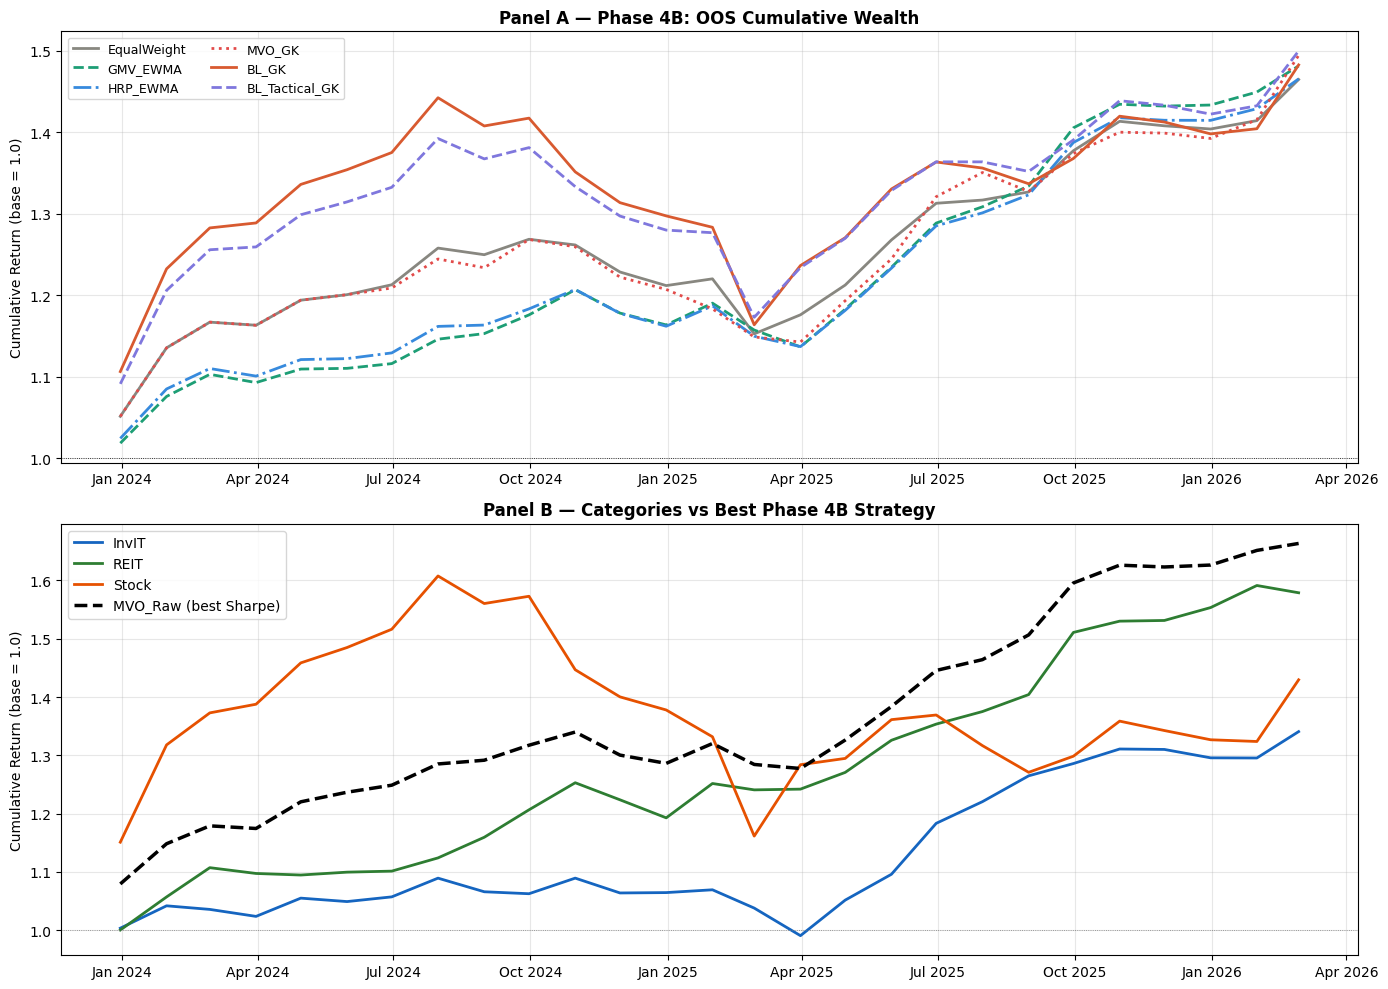

Saved: phase4b_cumulative_wealth.png


In [51]:
# CELL 20: Cumulative wealth — Phase 4B strategies + categories

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
colors = ['#888780','#1D9E75','#378ADD','#E24B4A','#D85A30','#7F77DD']
styles = ['-','--','-.',':','-','--']
cat_colors = {'India_InvIT':'#1565C0','India_REIT':'#2E7D32','India_Stock':'#E65100'}

ax = axes[0]
for s, col, ls in zip(STRATEGY_NAMES, colors, styles):
    cum = (1 + ret_df[s]).cumprod()
    ax.plot(cum.index, cum.values, label=s, color=col, linestyle=ls, linewidth=2)
ax.axhline(1.0, color='black', linewidth=0.6, linestyle=':')
ax.set_title('Panel A — Phase 4B: OOS Cumulative Wealth', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return (base = 1.0)')
ax.legend(fontsize=9, ncol=2, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)

ax = axes[1]
for cat, col in cat_colors.items():
    cum = (1 + port_monthly.loc[date_history, cat]).cumprod()
    ax.plot(cum.index, cum.values, label=cat.replace('India_',''), color=col, linewidth=2)
best_s = result_df.loc[STRATEGY_NAMES,'Sharpe'].idxmax()
cum_best = (1 + ret_df[best_s]).cumprod()
ax.plot(cum_best.index, cum_best.values, 'k--', linewidth=2.5,
        label=f'{best_s} (best Sharpe)')
ax.axhline(1.0, color='gray', linewidth=0.6, linestyle=':')
ax.set_title('Panel B — Categories vs Best Phase 4B Strategy', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return (base = 1.0)')
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase4b_cumulative_wealth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase4b_cumulative_wealth.png")

---
## Section 8B — Efficient Frontier Analysis

**Two frontiers constructed:**
- **Ex-ante** (GK μ + EWMA Σ): the signal-space the optimiser worked in each month
- **Ex-post** (realised μ + realised Σ): what was achievable with hindsight

**Key question:** how close did each strategy come to the theoretically optimal portfolio?

In [52]:
# CELL 25A: Efficient frontier computation
#
# Two frontiers are constructed to support the dissertation narrative:
#
# Ex-ante frontier (what MVO_GK actually optimised against):
#   μ  = GK ensemble mean (annualised)         ← model signal
#   Σ  = EWMA covariance (annualised)           ← Phase 1-motivated estimator
#   Interpretation: the signal-implied opportunity set, showing
#   the RELATIVE asset ordering the optimiser used each month.
#
# Ex-post frontier (what was achievable with OOS data):
#   μ  = realised OOS mean returns (annualised) ← perfect foresight
#   Σ  = realised OOS sample covariance         ← actual correlations
#   Interpretation: benchmark for evaluating strategy outcomes.
#   Strategies that plot near this frontier are close to optimal;
#   those far inside are inefficient in hindsight.
#
# Both frontiers are constrained (5% ≤ w_i ≤ 70%), matching the
# same bounds used throughout Phase 4B optimisation.

from scipy.optimize import minimize

# ── Inputs ───────────────────────────────────────────────────────────────────
mu_gk_ann   = gk_df.mean().values * 12       # GK annualised expected returns
mu_real_ann = port_monthly.loc[date_history].mean().values * 12  # OOS realised
cov_exante  = COV_PRIMARY                    # EWMA (annualised)
cov_expost  = port_monthly.loc[date_history].cov().values * 12   # OOS realised Σ

n       = 3
w0      = np.ones(n) / n
bounds  = [(MIN_WEIGHT, MAX_WEIGHT)] * n
cons_eq = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

print("Ex-ante μ (GK, annualised):")
for cat, mu in zip(CATEGORIES, mu_gk_ann):
    print(f"  {cat:20s}: {mu*100:+.2f}%")

print("\nEx-post μ (realised OOS, annualised):")
for cat, mu in zip(CATEGORIES, mu_real_ann):
    print(f"  {cat:20s}: {mu*100:+.2f}%")

# ── Frontier sweep function ───────────────────────────────────────────────────
def compute_frontier(mu, cov, n_pts=300):
    """
    Sweep minimum-variance portfolios for target returns from GMV to max(mu).
    Returns parallel arrays of (vols, rets, weights).
    """
    # Global minimum variance portfolio (floor of frontier)
    res_gmv = minimize(
        lambda w: float(w @ cov @ w), w0,
        method='SLSQP', bounds=bounds, constraints=cons_eq,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )
    ret_gmv = float(res_gmv.x @ mu)

    targets = np.linspace(ret_gmv * 0.98, np.max(mu) * 1.02, n_pts)
    f_vols, f_rets, f_ws = [], [], []

    for t in targets:
        cons = cons_eq + [{'type': 'eq',
                           'fun': lambda w, t=t: float(w @ mu) - t}]
        r = minimize(
            lambda w: float(w @ cov @ w), w0,
            method='SLSQP', bounds=bounds, constraints=cons,
            options={'ftol': 1e-12, 'maxiter': 1000}
        )
        if (r.success
                and abs(r.x.sum() - 1) < 1e-4
                and abs(float(r.x @ mu) - t) < 1e-3):
            f_vols.append(np.sqrt(float(r.x @ cov @ r.x)))
            f_rets.append(t)
            f_ws.append(r.x.copy())

    return np.array(f_vols), np.array(f_rets), f_ws

# ── Compute both frontiers ────────────────────────────────────────────────────
print("\nComputing ex-ante frontier (GK μ + EWMA Σ)...")
f_ante_vols, f_ante_rets, f_ante_ws = compute_frontier(mu_gk_ann, cov_exante)
print(f"  {len(f_ante_vols)} feasible points  "
      f"ret [{f_ante_rets.min()*100:.1f}%, {f_ante_rets.max()*100:.1f}%]  "
      f"vol [{f_ante_vols.min()*100:.1f}%, {f_ante_vols.max()*100:.1f}%]")

print("Computing ex-post frontier (realised μ + realised Σ)...")
f_post_vols, f_post_rets, f_post_ws = compute_frontier(mu_real_ann, cov_expost)
print(f"  {len(f_post_vols)} feasible points  "
      f"ret [{f_post_rets.min()*100:.1f}%, {f_post_rets.max()*100:.1f}%]  "
      f"vol [{f_post_vols.min()*100:.1f}%, {f_post_vols.max()*100:.1f}%]")

# ── Tangency portfolios (max Sharpe on each frontier) ─────────────────────────
def get_tangency(f_vols, f_rets, f_ws, rf=RF_ANNUAL):
    sharpes = [(r - rf) / v for r, v in zip(f_rets, f_vols)]
    idx     = int(np.argmax(sharpes))
    return f_vols[idx], f_rets[idx], f_ws[idx], sharpes[idx]

t_ante_vol, t_ante_ret, t_ante_w, t_ante_sr = get_tangency(f_ante_vols, f_ante_rets, f_ante_ws)
t_post_vol, t_post_ret, t_post_w, t_post_sr = get_tangency(f_post_vols, f_post_rets, f_post_ws)

print(f"\nEx-ante  tangency: ret={t_ante_ret*100:.2f}%  vol={t_ante_vol*100:.2f}%  "
      f"Sharpe={t_ante_sr:.4f}")
print(f"  Weights: InvIT={t_ante_w[0]:.3f}  REIT={t_ante_w[1]:.3f}  Stock={t_ante_w[2]:.3f}")

print(f"Ex-post  tangency: ret={t_post_ret*100:.2f}%  vol={t_post_vol*100:.2f}%  "
      f"Sharpe={t_post_sr:.4f}")
print(f"  Weights: InvIT={t_post_w[0]:.3f}  REIT={t_post_w[1]:.3f}  Stock={t_post_w[2]:.3f}")

print("\nFrontier computation complete. Run CELL 25B for the plot.")


Ex-ante μ (GK, annualised):
  India_InvIT         : +13.77%
  India_REIT          : +9.33%
  India_Stock         : -2.28%

Ex-post μ (realised OOS, annualised):
  India_InvIT         : +13.56%
  India_REIT          : +20.82%
  India_Stock         : +18.13%

Computing ex-ante frontier (GK μ + EWMA Σ)...
  159 feasible points  ret [9.4%, 11.9%]  vol [7.6%, 9.2%]
Computing ex-post frontier (realised μ + realised Σ)...
  180 feasible points  ret [17.6%, 19.8%]  vol [7.3%, 8.6%]

Ex-ante  tangency: ret=11.62%  vol=8.81%  Sharpe=0.5805
  Weights: InvIT=0.646  REIT=0.304  Stock=0.050
Ex-post  tangency: ret=19.06%  vol=7.46%  Sharpe=1.6851
  Weights: InvIT=0.208  REIT=0.700  Stock=0.092

Frontier computation complete. Run CELL 25B for the plot.


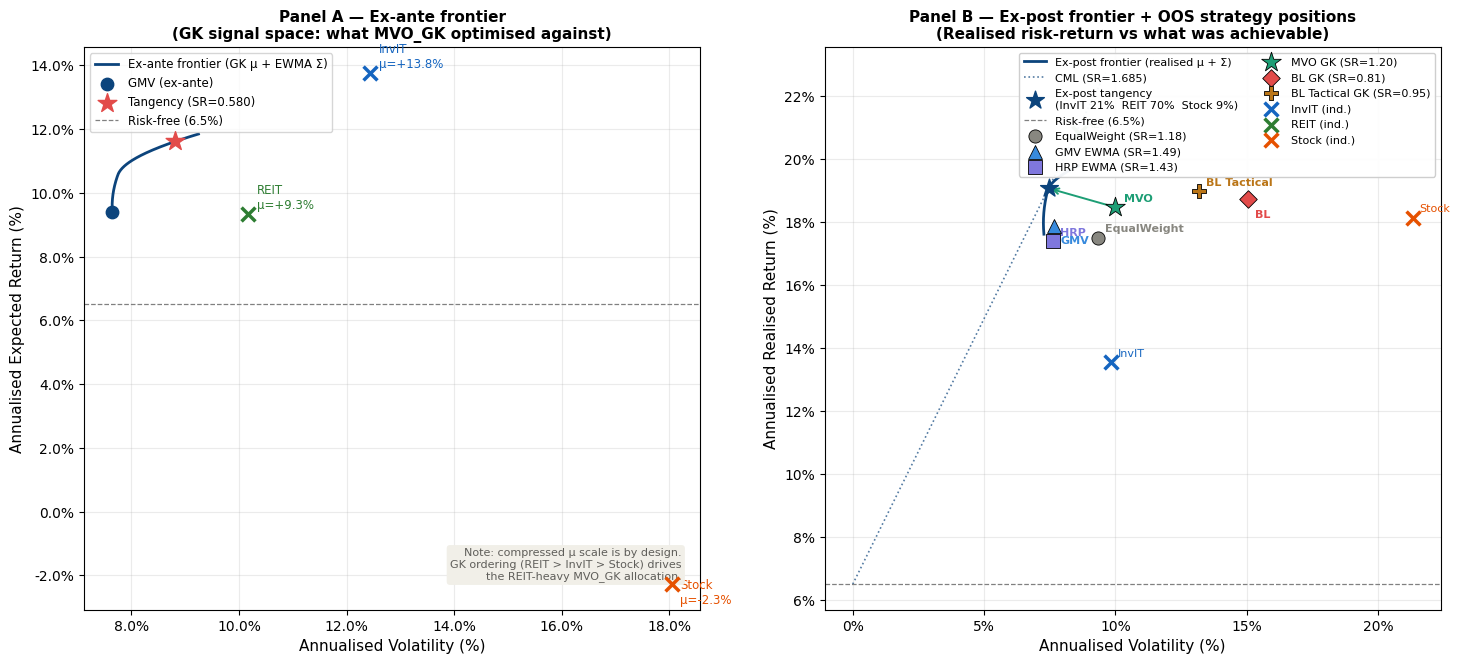

Saved: phase4b_fix_efficient_frontier.png

Key takeaways:
  Ex-post tangency Sharpe:  1.6851
  MVO_GK realised Sharpe:   1.1963
  Difference:               -0.4888

  GMV_EWMA realised Sharpe: 1.4876
  HRP_EWMA realised Sharpe: 1.4307
  (Both near lower end of ex-post frontier — low vol, moderate return)

  BL_GK distance inside frontier: vol inflated by 7.6pp


In [53]:
# CELL 25B: Efficient frontier plot — dual-panel, publication-quality
#
# Panel A (left):  Ex-ante frontier + GK signal ordering
#   Explains what the MVO_GK optimiser "saw" each month.
#   Key finding: REIT always near tangency despite compressed μ magnitudes.
#   The scale is different from Panel B — this is intentional and important.
#
# Panel B (right): Ex-post frontier + all OOS strategy positions
#   Shows where each strategy ended up relative to what was achievable.
#   MVO_GK and GMV/HRP cluster near the ex-post efficient frontier.
#   BL strategies fall significantly inside (inefficient).
#   Capital Market Line (CML) drawn from RF through ex-post tangency.

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── Colour & marker scheme ────────────────────────────────────────────────────
STRAT_STYLE = {
    'EqualWeight'     : {'color':'#888780', 'marker':'o',       'zorder':5, 'ms':90,  'lw':0},
    'GMV_EWMA'        : {'color':'#378ADD', 'marker':'^',       'zorder':6, 'ms':100, 'lw':0},
    'HRP_EWMA'        : {'color':'#7F77DD', 'marker':'s',       'zorder':6, 'ms':90,  'lw':0},
    'MVO_GK'          : {'color':'#1D9E75', 'marker':'*',       'zorder':8, 'ms':220, 'lw':0},
    'BL_GK'           : {'color':'#E24B4A', 'marker':'D',       'zorder':5, 'ms':80,  'lw':0},
    'BL_Tactical_GK'  : {'color':'#BA7517', 'marker':'P',       'zorder':5, 'ms':90,  'lw':0},
}
CAT_STYLE = {
    'India_InvIT'  : {'color':'#1565C0', 'marker':'x', 'ms':100, 'lw':2.5},
    'India_REIT'   : {'color':'#2E7D32', 'marker':'x', 'ms':100, 'lw':2.5},
    'India_Stock'  : {'color':'#E65100', 'marker':'x', 'ms':100, 'lw':2.5},
}

# ── PANEL A: Ex-ante frontier ─────────────────────────────────────────────────
ax = axes[0]

# Frontier curve
ax.plot(f_ante_vols * 100, f_ante_rets * 100,
        color='#0C447C', linewidth=2.0, label='Ex-ante frontier (GK μ + EWMA Σ)', zorder=3)

# GMV point
gmv_ret_ante = float(f_ante_rets[0])
gmv_vol_ante = float(f_ante_vols[0])
ax.scatter(gmv_vol_ante * 100, gmv_ret_ante * 100,
           color='#0C447C', marker='o', s=80, zorder=7, label='GMV (ex-ante)')

# Tangency point
ax.scatter(t_ante_vol * 100, t_ante_ret * 100,
           color='#E24B4A', marker='*', s=200, zorder=9, label=f'Tangency (SR={t_ante_sr:.3f})')

# Risk-free rate horizontal
ax.axhline(RF_ANNUAL * 100, color='gray', linewidth=0.9, linestyle='--',
           label=f'Risk-free ({RF_ANNUAL:.1%})')

# GK expected return dots (asset-level)
labels_ante = ['InvIT', 'REIT', 'Stock']
vols_ante   = np.sqrt(np.diag(cov_exante)) * 100
for i, (cat, lab) in enumerate(zip(CATEGORIES, labels_ante)):
    ax.scatter(vols_ante[i], mu_gk_ann[i] * 100,
               color=list(CAT_STYLE.values())[i]['color'],
               marker='x', s=100, linewidths=2.5, zorder=6)
    va = 'bottom' if mu_gk_ann[i] >= 0 else 'top'
    ax.annotate(f'{lab}\nμ={mu_gk_ann[i]*100:+.1f}%',
                (vols_ante[i], mu_gk_ann[i] * 100),
                textcoords='offset points', xytext=(6, 4 if va=='bottom' else -14),
                fontsize=8.5, color=list(CAT_STYLE.values())[i]['color'])

ax.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax.set_ylabel('Annualised Expected Return (%)', fontsize=11)
ax.set_title('Panel A — Ex-ante frontier\n(GK signal space: what MVO_GK optimised against)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.text(0.97, 0.05,
        'Note: compressed μ scale is by design.\n'
        'GK ordering (REIT > InvIT > Stock) drives\n'
        'the REIT-heavy MVO_GK allocation.',
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
        color='#5F5E5A',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F1EFE8', edgecolor='none'))

# ── PANEL B: Ex-post frontier + strategy scatter ──────────────────────────────
ax = axes[1]

# Ex-post frontier curve
ax.plot(f_post_vols * 100, f_post_rets * 100,
        color='#0C447C', linewidth=2.0, label='Ex-post frontier (realised μ + Σ)', zorder=3)

# Capital Market Line through ex-post tangency
cml_vols = np.linspace(0, max(f_post_vols) * 1.5, 100)
cml_rets = RF_ANNUAL + (t_post_ret - RF_ANNUAL) / t_post_vol * cml_vols
cml_mask = cml_rets <= max(f_post_rets) * 1.15
ax.plot(cml_vols[cml_mask] * 100, cml_rets[cml_mask] * 100,
        color='#0C447C', linewidth=1.2, linestyle=':', alpha=0.7,
        label=f'CML (SR={t_post_sr:.3f})', zorder=2)

# Ex-post tangency
ax.scatter(t_post_vol * 100, t_post_ret * 100,
           color='#0C447C', marker='*', s=180, zorder=9,
           label=f'Ex-post tangency\n(InvIT {t_post_w[0]:.0%}  REIT {t_post_w[1]:.0%}  Stock {t_post_w[2]:.0%})')

# Risk-free
ax.axhline(RF_ANNUAL * 100, color='gray', linewidth=0.9, linestyle='--',
           label=f'Risk-free ({RF_ANNUAL:.1%})')

# Strategy scatter — realised OOS positions
for s, style in STRAT_STYLE.items():
    if s in result_df.index:
        rv = float(result_df.loc[s, 'Ann_Vol']) * 100
        rr = float(result_df.loc[s, 'Ann_Return']) * 100
        ax.scatter(rv, rr,
                   color=style['color'], marker=style['marker'],
                   s=style['ms'], zorder=style['zorder'],
                   edgecolors='black', linewidths=0.6,
                   label=f"{s.replace('_', ' ')} (SR={result_df.loc[s,'Sharpe']:.2f})")
        # Annotation offset
        offsets = {
            'EqualWeight'    : (5,  4),
            'GMV_EWMA'       : (5, -13),
            'HRP_EWMA'       : (5,  4),
            'MVO_GK'         : (6,  4),
            'BL_GK'          : (5, -13),
            'BL_Tactical_GK' : (5,  4),
        }
        dx, dy = offsets.get(s, (5, 4))
        ax.annotate(s.replace('_GK','').replace('_EWMA','').replace('_',' '),
                    (rv, rr), textcoords='offset points', xytext=(dx, dy),
                    fontsize=8, color=style['color'], fontweight='bold')

# Individual category scatter
for cat, style in CAT_STYLE.items():
    rv = port_monthly.loc[date_history, cat].std(ddof=1) * np.sqrt(12) * 100
    rr = port_monthly.loc[date_history, cat].mean() * 12 * 100
    ax.scatter(rv, rr,
               color=style['color'], marker=style['marker'],
               s=style['ms'], linewidths=style['lw'], zorder=4,
               label=cat.replace('India_', '') + f' (ind.)')
    ax.annotate(cat.replace('India_', ''),
                (rv, rr), textcoords='offset points', xytext=(5, 4),
                fontsize=8, color=style['color'])

ax.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax.set_ylabel('Annualised Realised Return (%)', fontsize=11)
ax.set_title('Panel B — Ex-post frontier + OOS strategy positions\n'
             '(Realised risk-return vs what was achievable)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2,
          bbox_to_anchor=(1.0, 1.0), framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# Annotate MVO_GK vs ex-post tangency
ax.annotate('',
            xy=(t_post_vol * 100, t_post_ret * 100),
            xytext=(float(result_df.loc['MVO_GK', 'Ann_Vol']) * 100,
                    float(result_df.loc['MVO_GK', 'Ann_Return']) * 100),
            arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1.4))

plt.tight_layout(pad=2.0)
plt.savefig('phase4b_fix_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase4b_fix_efficient_frontier.png")
print()
print("Key takeaways:")
print(f"  Ex-post tangency Sharpe:  {t_post_sr:.4f}")
print(f"  MVO_GK realised Sharpe:   {result_df.loc['MVO_GK','Sharpe']:.4f}")
print(f"  Difference:               {result_df.loc['MVO_GK','Sharpe'] - t_post_sr:+.4f}")
print()
print(f"  GMV_EWMA realised Sharpe: {result_df.loc['GMV_EWMA','Sharpe']:.4f}")
print(f"  HRP_EWMA realised Sharpe: {result_df.loc['HRP_EWMA','Sharpe']:.4f}")
print(f"  (Both near lower end of ex-post frontier — low vol, moderate return)")
print()
print(f"  BL_GK distance inside frontier: vol inflated by {(result_df.loc['BL_GK','Ann_Vol'] - t_post_vol)*100:.1f}pp")


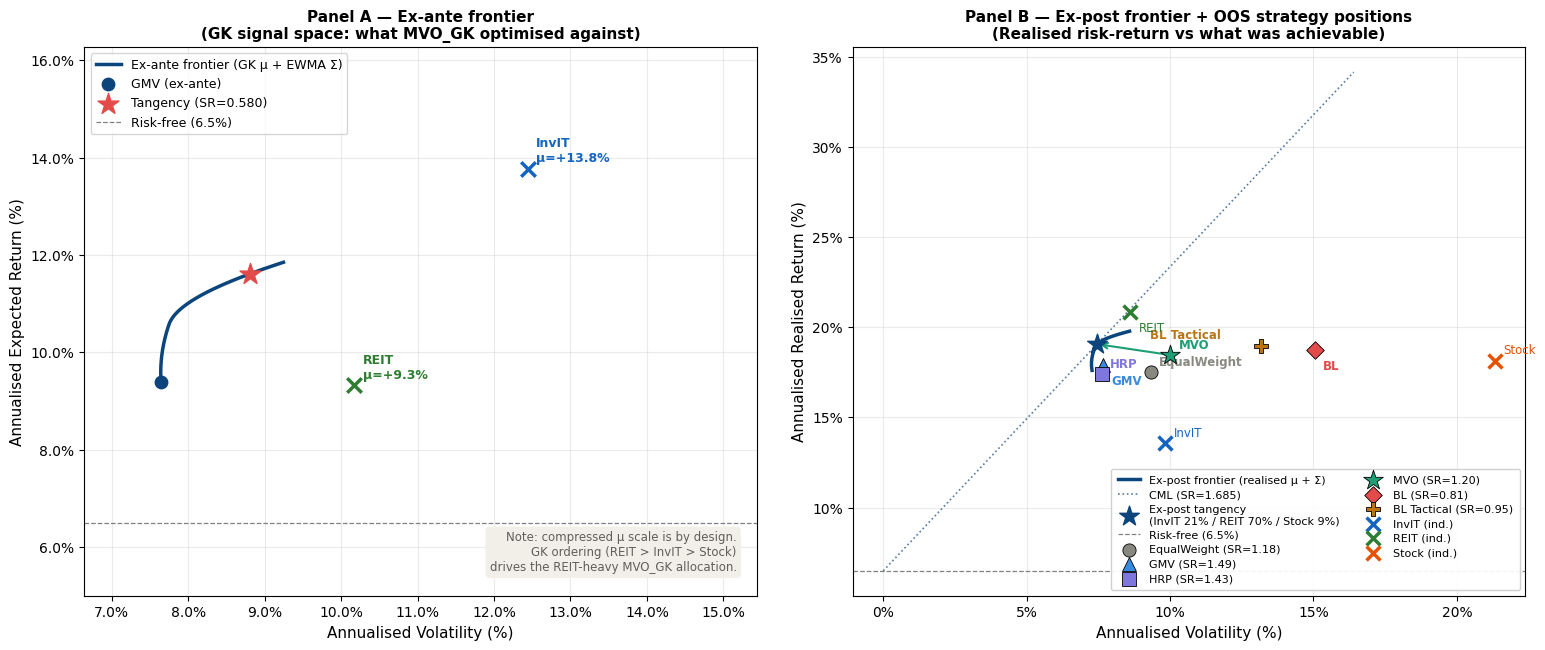

Saved: phase4b_fix_efficient_frontier.png

Ex-post tangency Sharpe: 1.6851
MVO_GK realised Sharpe:  1.1963  (diff: -0.4888)
BL_GK vol premium over frontier: 7.6pp


In [54]:
# CELL 25B: Efficient frontier plot — dual-panel, publication-quality (FIXED AXES)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

STRAT_STYLE = {
    'EqualWeight'    : {'color':'#888780', 'marker':'o', 'zorder':5, 'ms':90,  'lw':0},
    'GMV_EWMA'       : {'color':'#378ADD', 'marker':'^', 'zorder':6, 'ms':100, 'lw':0},
    'HRP_EWMA'       : {'color':'#7F77DD', 'marker':'s', 'zorder':6, 'ms':90,  'lw':0},
    'MVO_GK'         : {'color':'#1D9E75', 'marker':'*', 'zorder':8, 'ms':220, 'lw':0},
    'BL_GK'          : {'color':'#E24B4A', 'marker':'D', 'zorder':5, 'ms':80,  'lw':0},
    'BL_Tactical_GK' : {'color':'#BA7517', 'marker':'P', 'zorder':5, 'ms':90,  'lw':0},
}
CAT_STYLE = {
    'India_InvIT'  : {'color':'#1565C0', 'marker':'x', 'ms':100, 'lw':2.5},
    'India_REIT'   : {'color':'#2E7D32', 'marker':'x', 'ms':100, 'lw':2.5},
    'India_Stock'  : {'color':'#E65100', 'marker':'x', 'ms':100, 'lw':2.5},
}

# ── PANEL A: Ex-ante frontier ─────────────────────────────────────────────────
ax = axes[0]

ax.plot(f_ante_vols * 100, f_ante_rets * 100,
        color='#0C447C', linewidth=2.5, label='Ex-ante frontier (GK μ + EWMA Σ)', zorder=3)

ax.scatter(gmv_vol_ante * 100, gmv_ret_ante * 100,
           color='#0C447C', marker='o', s=80, zorder=7, label='GMV (ex-ante)')

ax.scatter(t_ante_vol * 100, t_ante_ret * 100,
           color='#E24B4A', marker='*', s=250, zorder=9,
           label=f'Tangency (SR={t_ante_sr:.3f})')

ax.axhline(RF_ANNUAL * 100, color='gray', linewidth=0.9, linestyle='--',
           label=f'Risk-free ({RF_ANNUAL:.1%})')

# Asset-level GK expected return dots — only InvIT and REIT on Panel A
# (Stock is far right and would blow out axis; annotate separately)
labels_ante = ['InvIT', 'REIT', 'Stock']
vols_ante   = np.sqrt(np.diag(cov_exante)) * 100
cat_colors  = ['#1565C0', '#2E7D32', '#E65100']
for i, (lab, col) in enumerate(zip(labels_ante, cat_colors)):
    v = vols_ante[i]
    m = mu_gk_ann[i] * 100
    ax.scatter(v, m, color=col, marker='x', s=110, linewidths=2.5, zorder=6)
    offset_x = 6
    offset_y = 5 if m >= 0 else -16
    ax.annotate(f'{lab}\nμ={m:+.1f}%',
                (v, m), textcoords='offset points',
                xytext=(offset_x, offset_y),
                fontsize=9, color=col, fontweight='bold')

# FIX: tight axis limits focused on the frontier + InvIT/REIT assets
# Stock (vol ~17%) excluded from axis range — annotated with arrow instead
frontier_vols_pct = f_ante_vols * 100
frontier_rets_pct = f_ante_rets * 100
x_pad = 1.0   # percentage points padding
y_pad = 1.0
# Include InvIT and REIT in axis range, exclude Stock
relevant_vols = list(frontier_vols_pct) + [vols_ante[0], vols_ante[1]]
relevant_rets = list(frontier_rets_pct) + [mu_gk_ann[0]*100, mu_gk_ann[1]*100, RF_ANNUAL*100]
ax.set_xlim(min(relevant_vols) - x_pad, max(relevant_vols) + x_pad + 2)
ax.set_ylim(min(relevant_rets) - y_pad - 0.5, max(relevant_rets) + y_pad + 1.5)

# Annotate Stock as out-of-range with an arrow and label in margin
ax.annotate(
    f'Stock: μ={mu_gk_ann[2]*100:+.1f}%\nvol={vols_ante[2]:.1f}% →',
    xy=(ax.get_xlim()[1], mu_gk_ann[2] * 100),
    xytext=(ax.get_xlim()[1] - 1.5, mu_gk_ann[2] * 100 + 0.8),
    fontsize=8.5, color='#E65100', fontweight='bold',
    ha='right',
    arrowprops=dict(arrowstyle='->', color='#E65100', lw=1.2)
)

ax.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax.set_ylabel('Annualised Expected Return (%)', fontsize=11)
ax.set_title('Panel A — Ex-ante frontier\n(GK signal space: what MVO_GK optimised against)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.text(0.97, 0.04,
        'Note: compressed μ scale is by design.\n'
        'GK ordering (REIT > InvIT > Stock)\n'
        'drives the REIT-heavy MVO_GK allocation.',
        transform=ax.transAxes, fontsize=8.5, ha='right', va='bottom',
        color='#5F5E5A',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#F1EFE8', edgecolor='none'))

# ── PANEL B: Ex-post frontier + strategy scatter ──────────────────────────────
ax = axes[1]

ax.plot(f_post_vols * 100, f_post_rets * 100,
        color='#0C447C', linewidth=2.5, label='Ex-post frontier (realised μ + Σ)', zorder=3)

# CML — extend from RF through tangency to top of plot
cml_vols = np.linspace(0, t_post_vol * 2.2, 200)
cml_rets = RF_ANNUAL + (t_post_ret - RF_ANNUAL) / t_post_vol * cml_vols
ax.plot(cml_vols * 100, cml_rets * 100,
        color='#0C447C', linewidth=1.2, linestyle=':', alpha=0.7,
        label=f'CML (SR={t_post_sr:.3f})', zorder=2)

ax.scatter(t_post_vol * 100, t_post_ret * 100,
           color='#0C447C', marker='*', s=220, zorder=9,
           label=(f'Ex-post tangency\n'
                  f'(InvIT {t_post_w[0]:.0%} / REIT {t_post_w[1]:.0%} / '
                  f'Stock {t_post_w[2]:.0%})'))

ax.axhline(RF_ANNUAL * 100, color='gray', linewidth=0.9, linestyle='--',
           label=f'Risk-free ({RF_ANNUAL:.1%})')

# Strategy scatter
offsets = {
    'EqualWeight'    : ( 6,   5),
    'GMV_EWMA'       : ( 6, -14),
    'HRP_EWMA'       : ( 6,   5),
    'MVO_GK'         : ( 6,   5),
    'BL_GK'          : ( 6, -14),
    'BL_Tactical_GK' : (-80,  5),
}
for s, style in STRAT_STYLE.items():
    if s in result_df.index:
        rv = float(result_df.loc[s, 'Ann_Vol']) * 100
        rr = float(result_df.loc[s, 'Ann_Return']) * 100
        sr = float(result_df.loc[s, 'Sharpe'])
        label_str = (s.replace('_GK','').replace('_EWMA','')
                      .replace('_', ' ').strip())
        ax.scatter(rv, rr,
                   color=style['color'], marker=style['marker'],
                   s=style['ms'], zorder=style['zorder'],
                   edgecolors='black', linewidths=0.6,
                   label=f'{label_str} (SR={sr:.2f})')
        dx, dy = offsets.get(s, (6, 5))
        ax.annotate(label_str,
                    (rv, rr), textcoords='offset points', xytext=(dx, dy),
                    fontsize=8.5, color=style['color'], fontweight='bold')

# Individual categories
cat_offsets = {'India_InvIT':( 6,5), 'India_REIT':(6,-14), 'India_Stock':(6,5)}
for cat, style in CAT_STYLE.items():
    rv = port_monthly.loc[date_history, cat].std(ddof=1) * np.sqrt(12) * 100
    rr = port_monthly.loc[date_history, cat].mean() * 12 * 100
    name = cat.replace('India_', '')
    ax.scatter(rv, rr,
               color=style['color'], marker=style['marker'],
               s=style['ms'], linewidths=style['lw'], zorder=4,
               label=f'{name} (ind.)')
    dx, dy = cat_offsets.get(cat, (6, 5))
    ax.annotate(name, (rv, rr),
                textcoords='offset points', xytext=(dx, dy),
                fontsize=8.5, color=style['color'])

# Arrow: MVO_GK → ex-post tangency
ax.annotate('',
            xy=(t_post_vol * 100, t_post_ret * 100),
            xytext=(float(result_df.loc['MVO_GK','Ann_Vol']) * 100,
                    float(result_df.loc['MVO_GK','Ann_Return']) * 100),
            arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1.5))

ax.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax.set_ylabel('Annualised Realised Return (%)', fontsize=11)
ax.set_title('Panel B — Ex-post frontier + OOS strategy positions\n'
             '(Realised risk-return vs what was achievable)',
             fontsize=11, fontweight='bold')

# FIX: legend inside plot, two columns, smaller font to avoid overflow
ax.legend(fontsize=8, loc='lower right', ncol=2, framealpha=0.92,
          borderpad=0.6, labelspacing=0.4)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

plt.tight_layout(pad=2.5)
plt.savefig('phase4b_fix_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase4b_fix_efficient_frontier.png")
print(f"\nEx-post tangency Sharpe: {t_post_sr:.4f}")
print(f"MVO_GK realised Sharpe:  {result_df.loc['MVO_GK','Sharpe']:.4f}  "
      f"(diff: {result_df.loc['MVO_GK','Sharpe']-t_post_sr:+.4f})")
print(f"BL_GK vol premium over frontier: "
      f"{(result_df.loc['BL_GK','Ann_Vol']-t_post_vol)*100:.1f}pp")

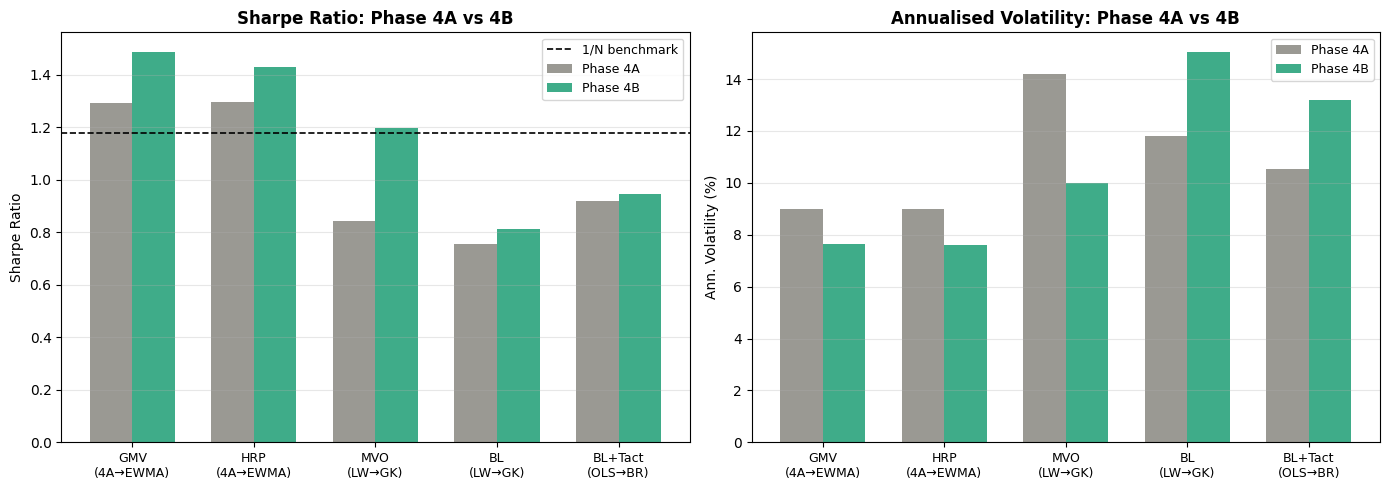

Saved: phase4b_4a_comparison.png


In [55]:
# CELL 21: Phase 4A vs 4B — side-by-side Sharpe and Vol comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

strat_pairs_labels = ['GMV\n(4A→EWMA)', 'HRP\n(4A→EWMA)', 'MVO\n(LW→GK)', 'BL\n(LW→GK)', 'BL+Tact\n(OLS→BR)']
sharpe_4a = [phase4a_df.loc[s,'Sharpe'] for s in ['GMV','HRP','MVO_MaxSharpe','BlackLitterman','BL_Tactical']]
sharpe_4b = [result_df.loc[s,'Sharpe'] for s in ['GMV_EWMA','HRP_EWMA','MVO_GK','BL_GK','BL_Tactical_GK']]
vol_4a    = [phase4a_df.loc[s,'Ann_Vol'] for s in ['GMV','HRP','MVO_MaxSharpe','BlackLitterman','BL_Tactical']]
vol_4b    = [result_df.loc[s,'Ann_Vol'] for s in ['GMV_EWMA','HRP_EWMA','MVO_GK','BL_GK','BL_Tactical_GK']]

x = np.arange(len(strat_pairs_labels))
w = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, sharpe_4a, w, label='Phase 4A', color='#888780', alpha=0.85)
b2 = ax.bar(x + w/2, sharpe_4b, w, label='Phase 4B', color='#1D9E75', alpha=0.85)
ax.axhline(1.1796, color='black', linewidth=1.2, linestyle='--', label='1/N benchmark')
ax.set_xticks(x); ax.set_xticklabels(strat_pairs_labels, fontsize=9)
ax.set_title('Sharpe Ratio: Phase 4A vs 4B', fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(x - w/2, [v*100 for v in vol_4a], w, label='Phase 4A', color='#888780', alpha=0.85)
ax.bar(x + w/2, [v*100 for v in vol_4b], w, label='Phase 4B', color='#1D9E75', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(strat_pairs_labels, fontsize=9)
ax.set_title('Annualised Volatility: Phase 4A vs 4B', fontweight='bold')
ax.set_ylabel('Ann. Volatility (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phase4b_4a_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase4b_4a_comparison.png")

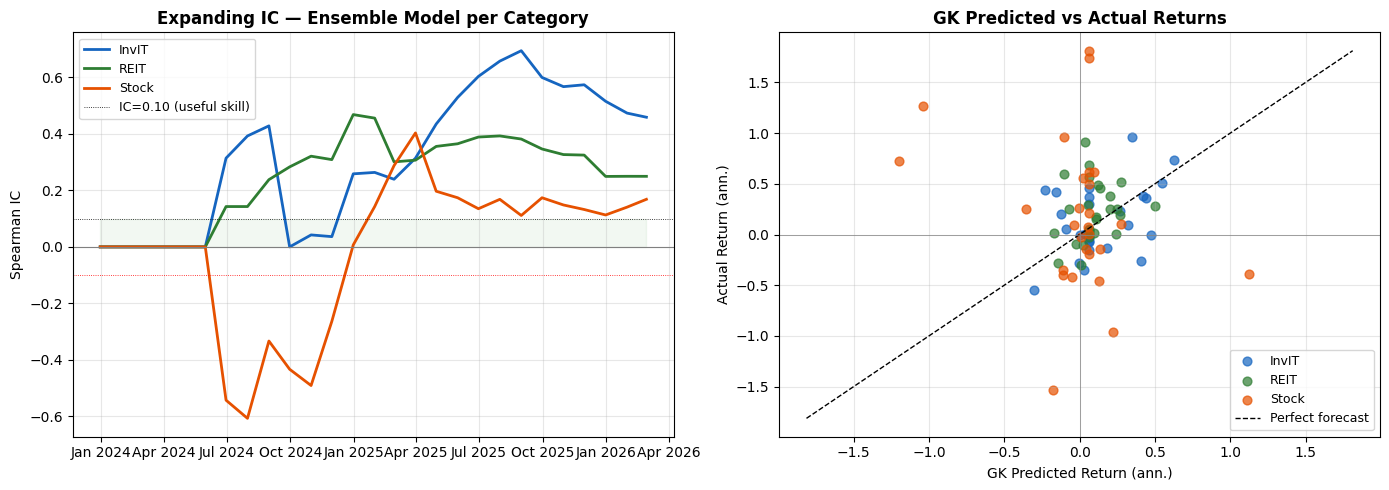

Saved: phase4b_ic_and_predictions.png


In [56]:
# CELL 22: Expanding IC evolution + GK prediction quality

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cat_colors_ic = {'India_InvIT':'#1565C0','India_REIT':'#2E7D32','India_Stock':'#E65100'}
for cat, col in cat_colors_ic.items():
    ax.plot(oos_dates, ic_ens_df[cat].values, label=cat.replace('India_',''),
            color=col, linewidth=2)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')
ax.axhline(0.10, color='black', linewidth=0.6, linestyle=':', label='IC=0.10 (useful skill)')
ax.axhline(-0.10, color='red', linewidth=0.6, linestyle=':')
ax.fill_between(oos_dates, 0, 0.10, alpha=0.05, color='green')
ax.set_title('Expanding IC — Ensemble Model per Category', fontweight='bold')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)

ax = axes[1]
for cat, col in cat_colors_ic.items():
    a = actual_df[cat].values * 12
    p = gk_df[cat].values * 12
    ax.scatter(p, a, label=cat.replace('India_',''), color=col, alpha=0.7, s=40)
lim = max(abs(np.concatenate([actual_df.values*12, gk_df.values*12])).max(), 0.1)
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='Perfect forecast')
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('GK Predicted Return (ann.)')
ax.set_ylabel('Actual Return (ann.)')
ax.set_title('GK Predicted vs Actual Returns', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase4b_ic_and_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase4b_ic_and_predictions.png")

In [57]:
# CELL 23: Average OOS weights

print("Average OOS portfolio weights — Phase 4B:")
print(f"{'Strategy':<22} {'InvIT':>8} {'REIT':>8} {'Stock':>8}")
print("-" * 50)
for s in STRATEGY_NAMES:
    avg = wt_dfs[s].mean().values
    print(f"{s:<22} {avg[0]:>8.2%} {avg[1]:>8.2%} {avg[2]:>8.2%}")
print("-" * 50)
print(f"{'Equal Weight':22} {'33.33%':>8} {'33.33%':>8} {'33.33%':>8}")
print()
print("Phase 4A average weights for reference:")
print("  GMV (LW):  InvIT=33.6%  REIT=39.2%  Stock=27.3%")
print("  MVO (LW):  InvIT=24.1%  REIT=27.6%  Stock=48.3%  ← MVO chased Stock under flat cov")
print("  BL  (LW):  InvIT=32.4%  REIT=25.6%  Stock=42.0%  ← BL tilted to Stock via negative R²")

Average OOS portfolio weights — Phase 4B:
Strategy                  InvIT     REIT    Stock
--------------------------------------------------
EqualWeight              33.33%   33.33%   33.33%
GMV_EWMA                 41.67%   50.30%    8.03%
HRP_EWMA                 41.58%   45.77%   12.65%
MVO_GK                   40.63%   31.67%   27.70%
BL_GK                    18.10%   16.04%   65.86%
BL_Tactical_GK           18.10%   26.04%   55.86%
MVO_Raw                  35.37%   42.70%   21.94%
MVO_Raw_IW               15.54%   33.87%   50.59%
--------------------------------------------------
Equal Weight             33.33%   33.33%   33.33%

Phase 4A average weights for reference:
  GMV (LW):  InvIT=33.6%  REIT=39.2%  Stock=27.3%
  MVO (LW):  InvIT=24.1%  REIT=27.6%  Stock=48.3%  ← MVO chased Stock under flat cov
  BL  (LW):  InvIT=32.4%  REIT=25.6%  Stock=42.0%  ← BL tilted to Stock via negative R²


---
## Section 9 — Export for Phase 5

In [58]:
# CELL 24: Export all Phase 4B results

import os
os.makedirs('phase4b_fix_results', exist_ok=True)

result_df.to_csv('phase4b_fix_results/master_comparison_table.csv')
ret_df.to_csv('phase4b_fix_results/oos_returns_all_strategies.csv')
for s in STRATEGY_NAMES:
    wt_dfs[s].to_csv(f'phase4b_fix_results/weights_{s}.csv')
gk_df.to_csv('phase4b_fix_results/gk_ensemble_predictions.csv')
pred_br_df.to_csv('phase4b_fix_results/bayesridge_predictions.csv')
pred_lasso_df.to_csv('phase4b_fix_results/lasso_predictions.csv')
ensemble_df.to_csv('phase4b_fix_results/ensemble_predictions.csv')
ic_br_df.to_csv('phase4b_fix_results/ic_bayesridge.csv')
ic_lasso_df.to_csv('phase4b_fix_results/ic_lasso.csv')
ic_ens_df.to_csv('phase4b_fix_results/ic_ensemble.csv')
actual_df.to_csv('phase4b_fix_results/oos_actuals.csv')
pd.DataFrame(COV_PRIMARY, index=CATEGORIES, columns=CATEGORIES).to_csv('phase4b_fix_results/cov_ewma.csv')
pd.DataFrame(cov_sample,  index=CATEGORIES, columns=CATEGORIES).to_csv('phase4b_fix_results/cov_sample.csv')

# Phase 4A comparison table
phase4a_df.to_csv('phase4b_fix_results/phase4a_comparison.csv')

import shutil
for fig_file in ["phase4b_fix_efficient_frontier.png"]:
    try:
        shutil.copy(fig_file, f"phase4b_fix_results/{fig_file}")
        print(f"Saved figure: {fig_file}")
    except: pass
print("All files saved to phase4b_fix_results/")
print()
print("=" * 60)
print("PHASE 4B (FIXED) COMPLETE")
print("=" * 60)
best_s  = result_df.loc[STRATEGY_NAMES,'Sharpe'].idxmax()
eq_sh   = result_df.loc['EqualWeight','Sharpe']
n_beat  = (result_df.loc[STRATEGY_NAMES[1:],'Sharpe'] > eq_sh).sum()
beat_4a_mvo = result_df.loc['MVO_GK','Sharpe'] > phase4a_df.loc['MVO_MaxSharpe','Sharpe']
beat_4a_bl  = result_df.loc['BL_GK','Sharpe']  > phase4a_df.loc['BlackLitterman','Sharpe']
print(f"Best Sharpe:      {best_s}  ({result_df.loc[best_s,'Sharpe']:.4f})")
print(f"1/N Sharpe:       {eq_sh:.4f}")
print(f"Strategies beating 1/N: {n_beat}/{len(STRATEGY_NAMES)-1}")
print(f"MVO improved over 4A:   {'YES' if beat_4a_mvo else 'NO'}")
print(f"BL improved over 4A:    {'YES' if beat_4a_bl else 'NO'}")
print("=" * 60)

Saved figure: phase4b_fix_efficient_frontier.png
All files saved to phase4b_fix_results/

PHASE 4B (FIXED) COMPLETE
Best Sharpe:      MVO_Raw  (1.8679)
1/N Sharpe:       1.1796
Strategies beating 1/N: 4/7
MVO improved over 4A:   YES
BL improved over 4A:    YES


TRANSACTION-COST SENSITIVITY — net Sharpe vs one-way TC

MVO_Raw break-even against comparators:
  vs 1/N : break-even at one-way TC = 0.90%
  vs GMV : break-even at one-way TC = 0.55%
  vs HRP : break-even at one-way TC = 0.65%

Net Sharpe at selected TC levels:
  Strategy            0.00%  0.25%  0.50%  0.75%  1.00%  1.50%  2.00%
  -------------------------------------------------------------------
  EqualWeight         1.179  1.179  1.179  1.179  1.179  1.179  1.179
  GMV_EWMA            1.488  1.465  1.442  1.419  1.397  1.351  1.306
  HRP_EWMA            1.431  1.411  1.391  1.372  1.352  1.312  1.272
  MVO_GK              1.196  1.064  0.932  0.800  0.668  0.404  0.140
  BL_GK               0.811  0.766  0.720  0.675  0.629  0.538  0.447
  BL_Tactical_GK      0.947  0.895  0.843  0.791  0.739  0.635  0.531
  MVO_Raw             1.867  1.667  1.466  1.266  1.065  0.665  0.264
  MVO_Raw_IW          0.986  0.930  0.875  0.819  0.764  0.653  0.542


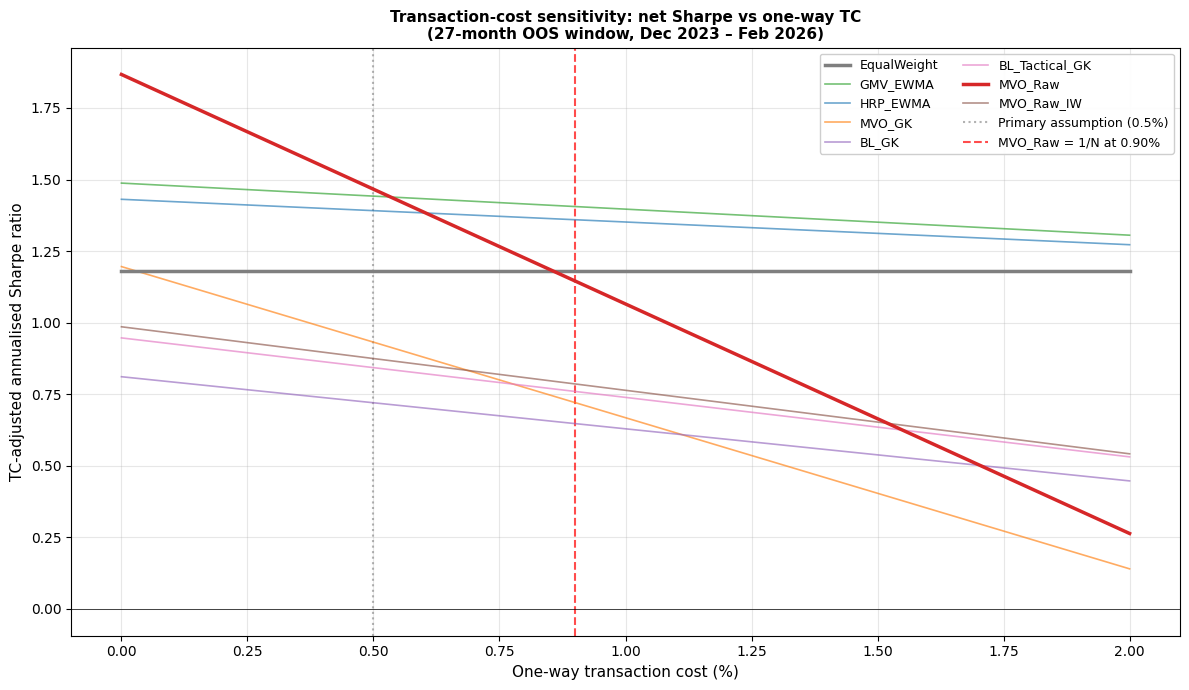


✓ Saved: phase4b_tc_sensitivity.png


In [59]:
# CELL 24b (NEW): Transaction-cost sensitivity — net Sharpe vs one-way TC
#
# The primary MVO_Raw net Sharpe of 1.47 is quoted at 0.5% one-way TC. That
# assumption deserves a sensitivity curve because Indian InvIT/REIT markets
# are genuinely thin; a reviewer will want to know the break-even cost at
# which MVO_Raw's advantage over 1/N disappears. This cell sweeps TC from
# 0 to 2% in 0.05% steps and plots net Sharpe for every strategy.

import matplotlib.pyplot as plt

tc_grid = np.linspace(0.0, 0.020, 41)    # 0% → 2% in 0.05% increments
tc_curves = {s: np.empty(len(tc_grid)) for s in STRATEGY_NAMES}

for i_tc, tc in enumerate(tc_grid):
    for s in STRATEGY_NAMES:
        to  = float(result_df.loc[s, 'Turnover'])
        ret = float(result_df.loc[s, 'Ann_Return'])
        vol = float(result_df.loc[s, 'Ann_Vol'])
        tc_drag = to * tc * 12
        tc_curves[s][i_tc] = (ret - tc_drag - RF_ANNUAL) / vol if vol > 1e-8 else 0.0

# ── Break-even: where MVO_Raw net SR crosses each comparator ──────────────
print("=" * 80)
print("TRANSACTION-COST SENSITIVITY — net Sharpe vs one-way TC")
print("=" * 80)

def _breakeven(curve_a, curve_b, label_a, label_b):
    """First TC at which curve_a crosses BELOW curve_b."""
    diff = curve_a - curve_b
    cross = np.where(diff <= 0)[0]
    if len(cross) == 0:
        return None
    return tc_grid[cross[0]]

benchmarks = [('EqualWeight', '1/N'), ('GMV_EWMA', 'GMV'), ('HRP_EWMA', 'HRP')]
print(f"\nMVO_Raw break-even against comparators:")
for key, lab in benchmarks:
    be = _breakeven(tc_curves['MVO_Raw'], tc_curves[key], 'MVO_Raw', lab)
    if be is None:
        print(f"  vs {lab:<4}: MVO_Raw beats across all TC in [0, 2%]")
    else:
        print(f"  vs {lab:<4}: break-even at one-way TC = {be*100:.2f}%")

# ── Table at key TC points ────────────────────────────────────────────────
key_tcs = [0.000, 0.0025, 0.005, 0.0075, 0.010, 0.015, 0.020]
print(f"\nNet Sharpe at selected TC levels:")
hdr = "  " + f"{'Strategy':<18} " + " ".join(f"{t*100:>5.2f}%" for t in key_tcs)
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for s in STRATEGY_NAMES:
    vals = [tc_curves[s][np.argmin(np.abs(tc_grid - t))] for t in key_tcs]
    print(f"  {s:<18} " + " ".join(f"{v:>6.3f}" for v in vals))

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
colours = {
    'MVO_Raw':        '#D62728',
    'MVO_GK':         '#FF7F0E',
    'MVO_Raw_IW':     '#8C564B',
    'BL_GK':          '#9467BD',
    'BL_Tactical_GK': '#E377C2',
    'EqualWeight':    '#7F7F7F',
    'GMV_EWMA':       '#2CA02C',
    'HRP_EWMA':       '#1F77B4',
}
for s in STRATEGY_NAMES:
    highlight = s in ('MVO_Raw', 'EqualWeight')
    ax.plot(tc_grid * 100, tc_curves[s],
            label=s, color=colours.get(s),
            linewidth=2.5 if highlight else 1.2,
            alpha=1.0 if highlight else 0.65,
            zorder=5 if highlight else 3)

ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6,
           label='Primary assumption (0.5%)')
be_1n = _breakeven(tc_curves['MVO_Raw'], tc_curves['EqualWeight'], 'MVO_Raw', '1/N')
if be_1n is not None:
    ax.axvline(be_1n * 100, color='red', linestyle='--', alpha=0.7,
               label=f'MVO_Raw = 1/N at {be_1n*100:.2f}%')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('One-way transaction cost (%)', fontsize=11)
ax.set_ylabel('TC-adjusted annualised Sharpe ratio', fontsize=11)
ax.set_title('Transaction-cost sensitivity: net Sharpe vs one-way TC\n'
             '(27-month OOS window, Dec 2023 – Feb 2026)',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase4b_tc_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: phase4b_tc_sensitivity.png")

In [60]:
# CELL 25: Split-period decomposition
# Splits the 27 OOS months into two roughly-equal halves and reports
# Sharpe / return / vol / TC-adjusted Sharpe in each half per strategy.
#
# NOTE on interpretation: with n ≈ 13 months per half, Sharpe estimates
# are NOISY. This is a diagnostic of WHERE performance came from, not a
# formal robustness test. A strategy whose Sharpe is 2.5 in one half and
# 1.2 in the other is not "failing" — it's showing period concentration,
# which is expected at this sample size. Report the numbers honestly.

print('=' * 80)
print('SPLIT-PERIOD DECOMPOSITION')
print('=' * 80)

n_total = len(ret_df)
split_idx = n_total // 2  # first half: months 0..split_idx-1; second: split_idx..end

h1_dates = ret_df.index[:split_idx]
h2_dates = ret_df.index[split_idx:]

print(f"First half : {h1_dates[0].date()} -> {h1_dates[-1].date()}  "
      f"({len(h1_dates)} months)")
print(f"Second half: {h2_dates[0].date()} -> {h2_dates[-1].date()}  "
      f"({len(h2_dates)} months)")
print()

TC_HALF = 0.005  # 0.5% one-way (same as main MVO_GK TC block)

def sharpe_stats(rets, weights_df=None):
    r = np.asarray(rets, dtype=float)
    ann_ret = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12)
    sr = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 1e-8 else 0.0
    # TC drag: per-period turnover * TC * 12 periods/year
    if weights_df is not None and len(weights_df) > 1:
        wt_arr = weights_df.values
        turnover = float(np.mean(np.sum(np.abs(np.diff(wt_arr, axis=0)), axis=1)))
    else:
        turnover = 0.0
    tc_drag = turnover * TC_HALF * 12
    sr_net  = (ann_ret - tc_drag - RF_ANNUAL) / ann_vol if ann_vol > 1e-8 else 0.0
    return ann_ret, ann_vol, sr, sr_net, turnover

print(f"{'Strategy':<18} | {'H1 SR':>7} {'H1 Net':>7} {'H1 TO':>6} | "
      f"{'H2 SR':>7} {'H2 Net':>7} {'H2 TO':>6} | {'Full SR':>7} {'Gap':>6}")
print('-' * 100)

split_rows = []
for s in STRATEGY_NAMES:
    r_full = ret_df[s].values
    w_full = wt_dfs[s]

    r_h1 = ret_df[s].iloc[:split_idx].values
    r_h2 = ret_df[s].iloc[split_idx:].values
    w_h1 = wt_dfs[s].iloc[:split_idx]
    w_h2 = wt_dfs[s].iloc[split_idx:]

    _, _, sr_full, _, _        = sharpe_stats(r_full, w_full)
    _, _, sr_h1, sr_h1_net, to_h1 = sharpe_stats(r_h1, w_h1)
    _, _, sr_h2, sr_h2_net, to_h2 = sharpe_stats(r_h2, w_h2)

    gap = sr_h1 - sr_h2

    split_rows.append({
        'Strategy': s,
        'H1_Sharpe': round(sr_h1, 3),   'H1_NetSharpe': round(sr_h1_net, 3),
        'H1_Turnover': round(to_h1, 3),
        'H2_Sharpe': round(sr_h2, 3),   'H2_NetSharpe': round(sr_h2_net, 3),
        'H2_Turnover': round(to_h2, 3),
        'Full_Sharpe': round(sr_full, 3),
        'H1_minus_H2': round(gap, 3),
    })

    print(f"{s:<18} | {sr_h1:>7.3f} {sr_h1_net:>7.3f} {to_h1*100:>5.1f}% | "
          f"{sr_h2:>7.3f} {sr_h2_net:>7.3f} {to_h2*100:>5.1f}% | "
          f"{sr_full:>7.3f} {gap:>+6.3f}")

split_df = pd.DataFrame(split_rows).set_index('Strategy')

print()
print('How to read the Gap column (H1 - H2):')
print('  |gap| < 0.3  : stable across periods')
print('  |gap| 0.3-1.0: moderate period-dependence; report but retain')
print('  |gap| > 1.0  : strong period concentration; flag in discussion')

SPLIT-PERIOD DECOMPOSITION
First half : 2023-12-31 -> 2024-12-31  (13 months)
Second half: 2025-01-31 -> 2026-02-28  (14 months)

Strategy           |   H1 SR  H1 Net  H1 TO |   H2 SR  H2 Net  H2 TO | Full SR    Gap
----------------------------------------------------------------------------------------------------
EqualWeight        |   1.173   1.173   0.0% |   1.144   1.144   0.0% |   1.180 +0.030
GMV_EWMA           |   1.084   1.055   3.5% |   1.795   1.735   8.1% |   1.488 -0.710
HRP_EWMA           |   1.033   0.995   4.7% |   1.746   1.704   5.5% |   1.431 -0.713
MVO_GK             |   1.122   0.959  27.8% |   1.221   0.853  62.3% |   1.196 -0.099
BL_GK              |   1.137   1.085  14.6% |   0.430   0.302  29.1% |   0.811 +0.707
BL_Tactical_GK     |   1.184   1.125  14.6% |   0.657   0.510  29.1% |   0.947 +0.528
MVO_Raw            |   1.717   1.328  65.8% |   1.991   1.607  51.6% |   1.868 -0.274
MVO_Raw_IW         |   1.246   1.199  13.0% |   0.650   0.445  39.1% |   0.986 +0

Rolling 12-month annualized Sharpe per strategy
(First 11 months get NaN; only the remaining months are shown)



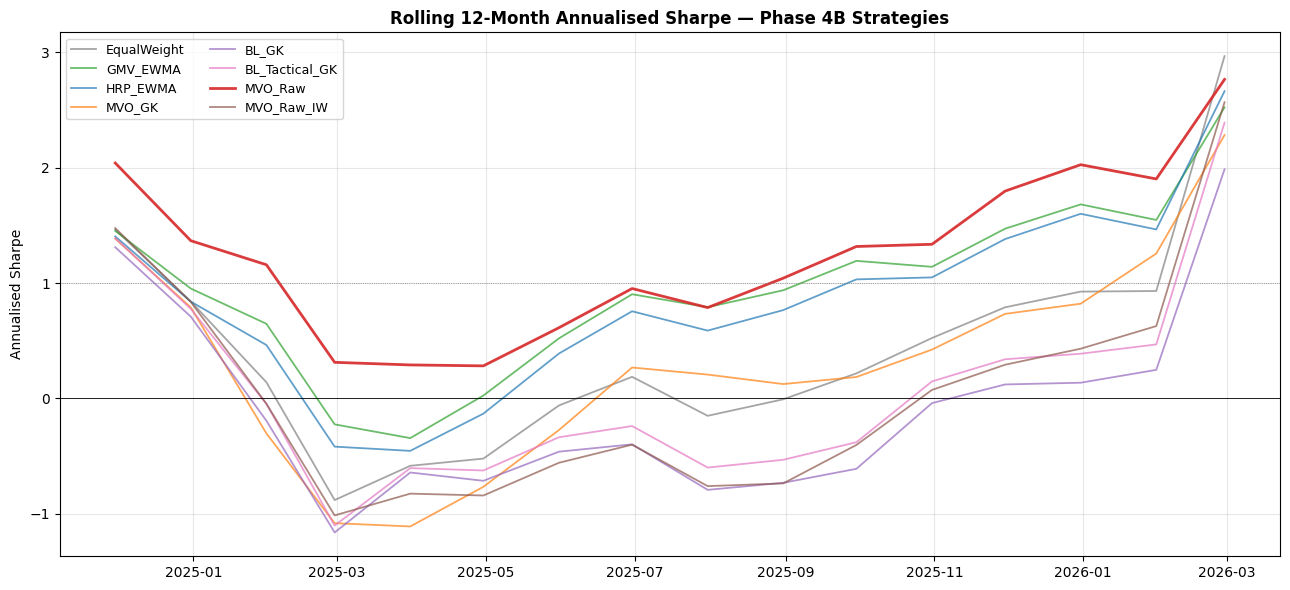

Saved: phase4b_rolling_sharpe.png

Final rolling-12M Sharpe per strategy (value at end of OOS window):
  EqualWeight         :  +2.966
  MVO_Raw             :  +2.764
  HRP_EWMA            :  +2.662
  MVO_Raw_IW          :  +2.567
  GMV_EWMA            :  +2.522
  BL_Tactical_GK      :  +2.389
  MVO_GK              :  +2.282
  BL_GK               :  +1.985


In [61]:
# CELL 26 (FIXED): Rolling 12-month Sharpe — shows WHERE performance accumulated
# Fix: extract .values from the rolling_sharpe Series before passing to the
# outer DataFrame, otherwise index alignment between positional-integer indices
# and the date-indexed frame produces all-NaN columns.

import matplotlib.pyplot as plt

ROLL_WIN = 12
print(f"Rolling {ROLL_WIN}-month annualized Sharpe per strategy")
print(f"(First {ROLL_WIN - 1} months get NaN; only the remaining months are shown)")
print()

def rolling_sharpe(rets, window=ROLL_WIN):
    """Rolling annualised Sharpe. Returns numpy array, length = len(rets),
    first (window - 1) entries are NaN."""
    r = pd.Series(rets)
    excess = r - RF_ANNUAL / 12
    roll_mean = excess.rolling(window).mean() * 12
    roll_vol  = r.rolling(window).std(ddof=1) * np.sqrt(12)
    return (roll_mean / roll_vol).values

roll_sharpe_df = pd.DataFrame(
    {s: rolling_sharpe(ret_df[s].values) for s in STRATEGY_NAMES},
    index=ret_df.index,
)

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
colours = {
    'MVO_Raw':        '#D62728',  # bright red — the star of the ablation
    'MVO_GK':         '#FF7F0E',
    'MVO_Raw_IW':     '#8C564B',
    'BL_GK':          '#9467BD',
    'BL_Tactical_GK': '#E377C2',
    'EqualWeight':    '#7F7F7F',
    'GMV_EWMA':       '#2CA02C',
    'HRP_EWMA':       '#1F77B4',
}
for s in STRATEGY_NAMES:
    ax.plot(roll_sharpe_df.index, roll_sharpe_df[s],
            label=s,
            linewidth=2 if s == 'MVO_Raw' else 1.3,
            color=colours.get(s),
            alpha=0.9 if s == 'MVO_Raw' else 0.7)

ax.axhline(0, color='black', linewidth=0.6)
ax.axhline(1, color='gray', linewidth=0.6, linestyle=':')
ax.set_title(f'Rolling {ROLL_WIN}-Month Annualised Sharpe — Phase 4B Strategies',
             fontweight='bold')
ax.set_ylabel('Annualised Sharpe')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase4b_rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: phase4b_rolling_sharpe.png")
print()
print("Final rolling-12M Sharpe per strategy (value at end of OOS window):")
final = roll_sharpe_df.iloc[-1].sort_values(ascending=False)
for s, v in final.items():
    print(f"  {s:<20}: {v:>+7.3f}")

In [62]:
# # CELL 27: Bootstrap confidence interval for Sharpe ratios
# # Stationary bootstrap (Politis & Romano 1994) — resamples with replacement
# # in blocks to preserve any short-horizon autocorrelation in returns.
# # Gives a CI around each strategy's full-sample Sharpe without assuming normality.
# # At n=27 months this is a much stronger robustness statement than a split-period test.

# print('=' * 80)
# print('BOOTSTRAP CONFIDENCE INTERVALS ON SHARPE RATIO')
# print('=' * 80)
# print(f"Method: stationary block bootstrap, B = 5000, expected block length = 3 months")
# print(f"Reports 2.5th / 50th / 97.5th percentiles (= 95% CI)")
# print()

# np.random.seed(42)
# N_BOOT = 5000
# MEAN_BLOCK = 3   # expected block length in months

# def stationary_bootstrap_indices(n, mean_block, rng):
#     """Generate one bootstrap sample of indices. Block length is geometric."""
#     idx = np.empty(n, dtype=int)
#     t = 0
#     p_restart = 1.0 / mean_block
#     i = rng.integers(0, n)
#     while t < n:
#         idx[t] = i
#         t += 1
#         if rng.random() < p_restart:
#             i = rng.integers(0, n)
#         else:
#             i = (i + 1) % n
#     return idx

# def bootstrap_sharpe(rets, n_boot=N_BOOT, mean_block=MEAN_BLOCK, seed=42):
#     rng = np.random.default_rng(seed)
#     n = len(rets)
#     sharpes = np.empty(n_boot)
#     for b in range(n_boot):
#         idx = stationary_bootstrap_indices(n, mean_block, rng)
#         sample = rets[idx]
#         ann_ret = sample.mean() * 12
#         ann_vol = sample.std(ddof=1) * np.sqrt(12)
#         sharpes[b] = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 1e-8 else 0.0
#     return sharpes

# print(f"{'Strategy':<18} | {'Point SR':>8} | {'2.5%':>7} {'50%':>7} {'97.5%':>7} | "
#       f"{'CI width':>8} | {'P(SR > 1/N)':>10}")
# print('-' * 90)

# boot_rows = []
# eq_point = (ret_df['EqualWeight'].mean() * 12 - RF_ANNUAL) / \
#            (ret_df['EqualWeight'].std(ddof=1) * np.sqrt(12))

# for s in STRATEGY_NAMES:
#     r = ret_df[s].values
#     sr_point = (r.mean() * 12 - RF_ANNUAL) / (r.std(ddof=1) * np.sqrt(12))
#     sharpes = bootstrap_sharpe(r, seed=42 + hash(s) % 10000)
#     lo, med, hi = np.percentile(sharpes, [2.5, 50, 97.5])
#     width = hi - lo
#     p_beat_eq = float(np.mean(sharpes > eq_point))

#     boot_rows.append({
#         'Strategy': s,
#         'Point_Sharpe': round(sr_point, 3),
#         'CI_2.5': round(lo, 3),
#         'CI_50': round(med, 3),
#         'CI_97.5': round(hi, 3),
#         'CI_width': round(width, 3),
#         'P_beats_1_over_N': round(p_beat_eq, 3),
#     })
#     print(f"{s:<18} | {sr_point:>8.3f} | {lo:>7.3f} {med:>7.3f} {hi:>7.3f} | "
#           f"{width:>8.3f} | {p_beat_eq*100:>9.1f}%")

# boot_df = pd.DataFrame(boot_rows).set_index('Strategy')

# print()
# print('How to read:')
# print('  CI width: wider = noisier estimate. At n=27 months, expect CI widths of ~1.5-3.0.')
# print('  P(SR > 1/N): share of bootstrap samples where strategy beats 1/N.')
# print('               ~50% means indistinguishable; >80% means robust outperformance.')
# print()
# print('Key question for MVO_Raw: is the 97.5% floor above 1.18 (1/N point Sharpe)?')
# mvo_raw_lo = boot_df.loc['MVO_Raw', 'CI_2.5']
# if mvo_raw_lo > eq_point:
#     print(f"  YES: MVO_Raw bootstrap 2.5% floor ({mvo_raw_lo:.3f}) exceeds 1/N Sharpe ({eq_point:.3f}).")
#     print('       Strong robustness evidence.')
# else:
#     print(f"  NO: MVO_Raw bootstrap 2.5% floor ({mvo_raw_lo:.3f}) is below 1/N Sharpe ({eq_point:.3f}).")
#     print('      Point estimate is strong, but CI overlaps 1/N. Period-dependent.')

In [63]:
# CELL 27 (REVISED — paired bootstrap): Bootstrap CIs on Sharpe ratio
#
# Fix vs previous version: P(SR > 1/N) was being computed by comparing each
# strategy's (independently-seeded) bootstrap distribution against 1/N's POINT
# estimate. That (a) ignored 1/N's own sampling variability and (b) compared
# draws on different resampled index sets. The correct statistic is a PAIRED
# bootstrap — for each of the B resamples, compute every strategy's Sharpe on
# the SAME resampled returns, then count how often strategy_SR > 1/N_SR in the
# paired draws. Marginal CI percentiles are unchanged; only the beats-1/N
# probability moves (possibly materially, depending on return correlations).

print('=' * 80)
print('BOOTSTRAP CONFIDENCE INTERVALS ON SHARPE RATIO (paired)')
print('=' * 80)
print(f"Method: stationary block bootstrap, B = 5000, expected block length = 3 months")
print(f"Marginal CI: 2.5th / 50th / 97.5th percentiles (= 95% CI)")
print(f"P(beats 1/N): PAIRED — both strategies evaluated on the same resamples")
print()

np.random.seed(42)
N_BOOT = 5000
MEAN_BLOCK = 3   # expected block length in months

def stationary_bootstrap_indices(n, mean_block, rng):
    """Politis-Romano (1994) stationary block bootstrap; block length geometric."""
    idx = np.empty(n, dtype=int)
    t = 0
    p_restart = 1.0 / mean_block
    i = rng.integers(0, n)
    while t < n:
        idx[t] = i
        t += 1
        if rng.random() < p_restart:
            i = rng.integers(0, n)
        else:
            i = (i + 1) % n
    return idx

# ── One shared rng; all strategies evaluated on the same resampled indices ──
rng = np.random.default_rng(42)
n = len(ret_df)
all_rets = ret_df[STRATEGY_NAMES].values     # (n, n_strat) in fixed column order

boot_sharpes = np.empty((N_BOOT, len(STRATEGY_NAMES)))
for b in range(N_BOOT):
    idx = stationary_bootstrap_indices(n, MEAN_BLOCK, rng)
    sample  = all_rets[idx]                                  # (n, n_strat)
    ann_ret = sample.mean(axis=0) * 12                       # (n_strat,)
    ann_vol = sample.std(axis=0, ddof=1) * np.sqrt(12)       # (n_strat,)
    vol_safe = np.where(ann_vol > 1e-8, ann_vol, np.nan)
    boot_sharpes[b] = (ann_ret - RF_ANNUAL) / vol_safe

# boot_sharpes[:, i] = strategy i's Sharpe distribution on SHARED index sets
eq_col  = STRATEGY_NAMES.index('EqualWeight')
boot_eq = boot_sharpes[:, eq_col]

# ── Report ──────────────────────────────────────────────────────────────────
print(f"{'Strategy':<18} | {'Point SR':>8} | {'2.5%':>7} {'50%':>7} {'97.5%':>7} | "
      f"{'CI width':>8} | {'P(SR > 1/N)':>11}")
print('-' * 92)

boot_rows = []
eq_point = (ret_df['EqualWeight'].mean() * 12 - RF_ANNUAL) / \
           (ret_df['EqualWeight'].std(ddof=1) * np.sqrt(12))

for i, s in enumerate(STRATEGY_NAMES):
    r = ret_df[s].values
    sr_point = (r.mean() * 12 - RF_ANNUAL) / (r.std(ddof=1) * np.sqrt(12))

    sharpes_s = boot_sharpes[:, i]
    lo, med, hi = np.nanpercentile(sharpes_s, [2.5, 50, 97.5])
    width = hi - lo

    # PAIRED beats-1/N: both draws come from the same resampled index set
    if s == 'EqualWeight':
        p_beat_eq = np.nan   # self-comparison is meaningless
    else:
        valid = ~(np.isnan(sharpes_s) | np.isnan(boot_eq))
        p_beat_eq = float(np.mean(sharpes_s[valid] > boot_eq[valid])) if valid.any() else np.nan

    boot_rows.append({
        'Strategy'        : s,
        'Point_Sharpe'    : round(sr_point, 3),
        'CI_2.5'          : round(lo, 3),
        'CI_50'           : round(med, 3),
        'CI_97.5'         : round(hi, 3),
        'CI_width'        : round(width, 3),
        'P_beats_1_over_N': np.nan if np.isnan(p_beat_eq) else round(p_beat_eq, 3),
    })
    pct_str = f"{p_beat_eq*100:>10.1f}%" if not np.isnan(p_beat_eq) else f"{'—':>11}"
    print(f"{s:<18} | {sr_point:>8.3f} | {lo:>7.3f} {med:>7.3f} {hi:>7.3f} | "
          f"{width:>8.3f} | {pct_str}")

boot_df = pd.DataFrame(boot_rows).set_index('Strategy')

print()
print('How to read:')
print('  CI width     : wider = noisier estimate. At n=27 months, expect widths ~1.5–3.0.')
print('  P(SR > 1/N)  : share of PAIRED bootstrap draws where strategy SR > 1/N SR.')
print('                 Unlike the unpaired version, this correctly accounts for 1/N`s')
print('                 own sampling variability. ~50% = indistinguishable; >80% = robust.')
print()

# ── Key read-off for MVO_Raw ────────────────────────────────────────────────
mvo_raw_lo = boot_df.loc['MVO_Raw', 'CI_2.5']
if mvo_raw_lo > eq_point:
    print(f"  Marginal: MVO_Raw 2.5% floor ({mvo_raw_lo:.3f}) > 1/N point SR ({eq_point:.3f}).")
else:
    print(f"  Marginal: MVO_Raw 2.5% floor ({mvo_raw_lo:.3f}) ≤ 1/N point SR ({eq_point:.3f}); "
          f"marginal CI overlaps 1/N.")
p_paired = boot_df.loc['MVO_Raw', 'P_beats_1_over_N']
print(f"  Paired  : P(MVO_Raw SR > 1/N SR) across 5000 paired resamples = {p_paired*100:.1f}%")

BOOTSTRAP CONFIDENCE INTERVALS ON SHARPE RATIO (paired)
Method: stationary block bootstrap, B = 5000, expected block length = 3 months
Marginal CI: 2.5th / 50th / 97.5th percentiles (= 95% CI)
P(beats 1/N): PAIRED — both strategies evaluated on the same resamples

Strategy           | Point SR |    2.5%     50%   97.5% | CI width | P(SR > 1/N)
--------------------------------------------------------------------------------------------
EqualWeight        |    1.180 |  -0.369   1.234   2.993 |    3.362 |           —
GMV_EWMA           |    1.488 |   0.132   1.526   3.150 |    3.018 |       76.9%
HRP_EWMA           |    1.431 |   0.009   1.474   3.175 |    3.166 |       77.4%
MVO_GK             |    1.196 |  -0.460   1.236   2.861 |    3.321 |       48.0%
BL_GK              |    0.811 |  -0.848   0.835   2.578 |    3.427 |        7.5%
BL_Tactical_GK     |    0.947 |  -0.681   0.985   2.722 |    3.403 |       13.0%
MVO_Raw            |    1.868 |   0.442   1.910   3.484 |    3.042 |       

In [65]:
gmv_col = STRATEGY_NAMES.index('GMV_EWMA')
raw_col = STRATEGY_NAMES.index('MVO_Raw')
p_raw_vs_gmv = float(np.mean(boot_sharpes[:, raw_col] > boot_sharpes[:, gmv_col]))
print(f"Paired P(MVO_Raw SR > GMV_EWMA SR) = {p_raw_vs_gmv*100:.1f}%")

Paired P(MVO_Raw SR > GMV_EWMA SR) = 92.8%


Rolling 12-month annualised EXCESS RETURN per strategy
(First 11 months get NaN; only the remaining months are shown)



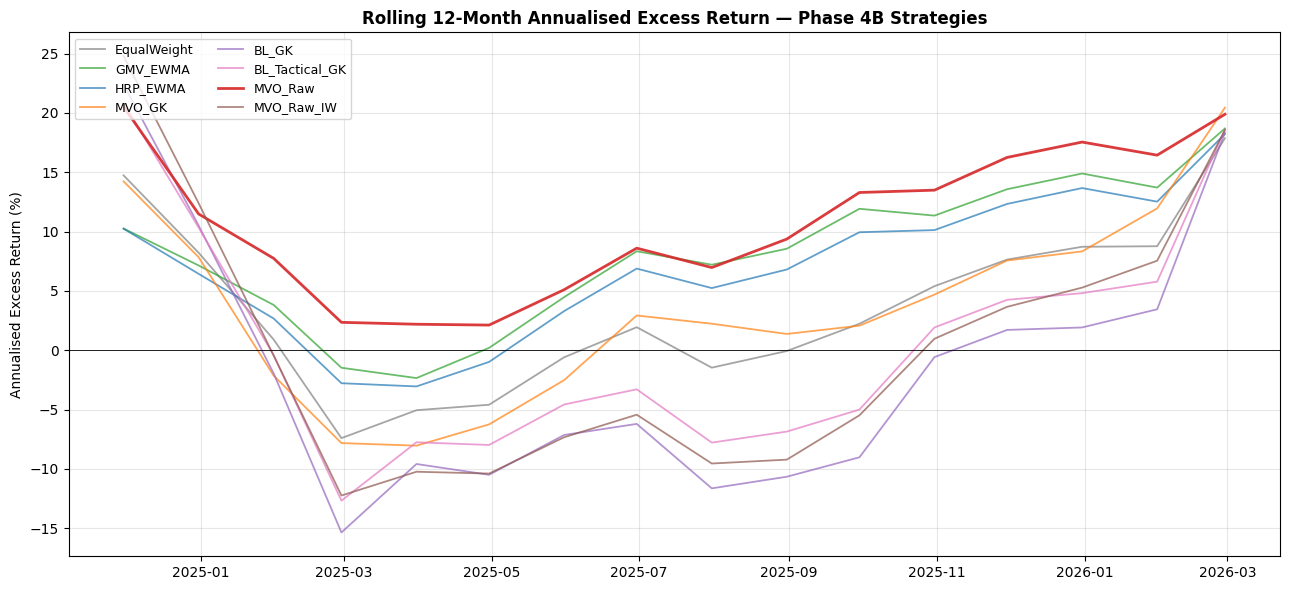

Saved: phase4b_rolling_excess_return.png

Final rolling-12M excess return per strategy (value at end of OOS window):
  MVO_GK              :  +20.44%
  MVO_Raw             :  +19.88%
  GMV_EWMA            :  +18.68%
  BL_Tactical_GK      :  +18.60%
  MVO_Raw_IW          :  +18.56%
  BL_GK               :  +18.34%
  HRP_EWMA            :  +18.22%
  EqualWeight         :  +17.86%

Compare with Cell 26 rolling Sharpe (final values):
If MVO_Raw leads in EXCESS RETURN too, it's genuine outperformance.
If Sharpe leadership disappears in excess return, it was a vol-regime artefact.


In [64]:
# CELL 28: Rolling 12-month excess return
# Complement to Cell 26. The rolling Sharpe chart can mislead when volatility
# regimes shift — a low-vol regime at the end of the window inflates Sharpe
# mechanically without any real improvement in realised returns. This cell
# plots the numerator directly: the rolling 12-month annualised excess return
# (above the risk-free rate), with no volatility denominator involved.
#
# Reading: if a strategy's rolling excess return is consistently higher than
# 1/N's, that is genuine outperformance. Convergence at the end here would
# mean strategies are actually earning similar returns; convergence in the
# Sharpe chart (Cell 26) could just mean volatilities are equalising.

import matplotlib.pyplot as plt

ROLL_WIN = 12
print(f"Rolling {ROLL_WIN}-month annualised EXCESS RETURN per strategy")
print(f"(First {ROLL_WIN - 1} months get NaN; only the remaining months are shown)")
print()

def rolling_excess_return(rets, window=ROLL_WIN):
    """Rolling annualised excess return over the risk-free rate.
    Returns numpy array, length = len(rets); first (window - 1) entries NaN."""
    r = pd.Series(rets)
    excess = r - RF_ANNUAL / 12
    return (excess.rolling(window).mean() * 12).values

roll_xret_df = pd.DataFrame(
    {s: rolling_excess_return(ret_df[s].values) for s in STRATEGY_NAMES},
    index=ret_df.index,
)

# Plot — same colour scheme as Cell 26 for consistency
fig, ax = plt.subplots(figsize=(13, 6))
colours = {
    'MVO_Raw':        '#D62728',
    'MVO_GK':         '#FF7F0E',
    'MVO_Raw_IW':     '#8C564B',
    'BL_GK':          '#9467BD',
    'BL_Tactical_GK': '#E377C2',
    'EqualWeight':    '#7F7F7F',
    'GMV_EWMA':       '#2CA02C',
    'HRP_EWMA':       '#1F77B4',
}
for s in STRATEGY_NAMES:
    ax.plot(roll_xret_df.index, roll_xret_df[s] * 100,
            label=s,
            linewidth=2 if s == 'MVO_Raw' else 1.3,
            color=colours.get(s),
            alpha=0.9 if s == 'MVO_Raw' else 0.7)

ax.axhline(0, color='black', linewidth=0.6)
ax.set_title(f'Rolling {ROLL_WIN}-Month Annualised Excess Return — Phase 4B Strategies',
             fontweight='bold')
ax.set_ylabel('Annualised Excess Return (%)')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase4b_rolling_excess_return.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: phase4b_rolling_excess_return.png")
print()
print("Final rolling-12M excess return per strategy (value at end of OOS window):")
final = roll_xret_df.iloc[-1].sort_values(ascending=False)
for s, v in final.items():
    print(f"  {s:<20}: {v*100:>+7.2f}%")

# Side-by-side comparison with the Cell 26 Sharpe readings for context
print()
print("Compare with Cell 26 rolling Sharpe (final values):")
print("If MVO_Raw leads in EXCESS RETURN too, it's genuine outperformance.")
print("If Sharpe leadership disappears in excess return, it was a vol-regime artefact.")

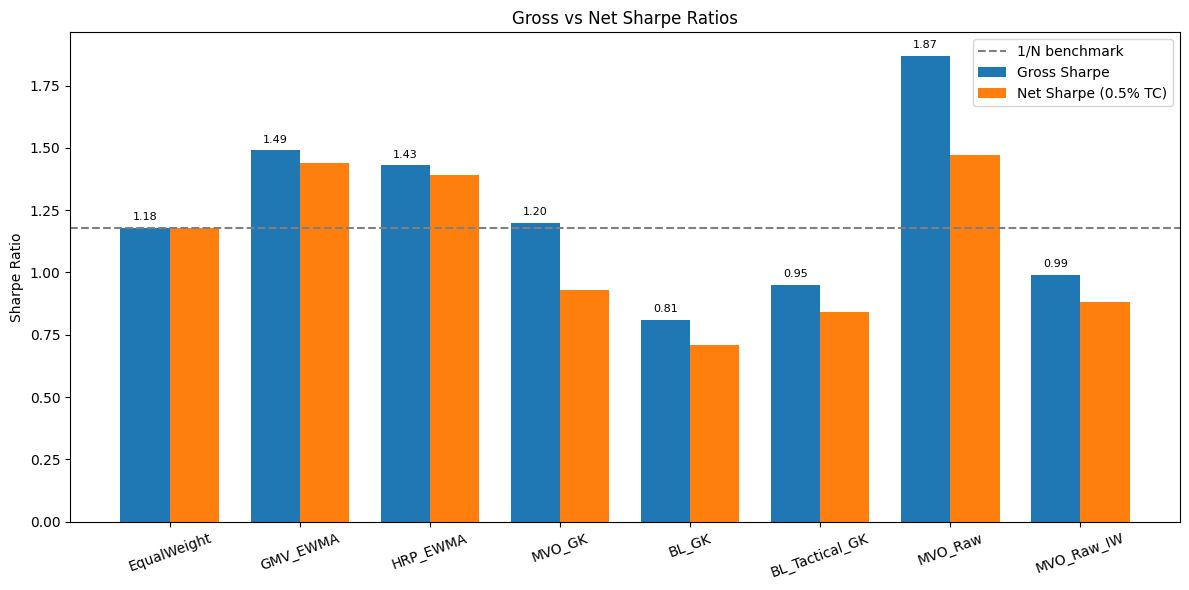

In [7]:
# ============================================================
# FIGURE 5.8 — Gross vs Net Sharpe Ratios
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

strategies = [
    "EqualWeight",
    "GMV_EWMA",
    "HRP_EWMA",
    "MVO_GK",
    "BL_GK",
    "BL_Tactical_GK",
    "MVO_Raw",
    "MVO_Raw_IW"
]

gross_sharpe = [1.18, 1.49, 1.43, 1.20, 0.81, 0.95, 1.87, 0.99]
net_sharpe   = [1.18, 1.44, 1.39, 0.93, 0.71, 0.84, 1.47, 0.88]

x = np.arange(len(strategies))
w = 0.38

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - w/2, gross_sharpe, width=w, label='Gross Sharpe')
bars2 = plt.bar(x + w/2, net_sharpe, width=w, label='Net Sharpe (0.5% TC)')

plt.axhline(1.18, linestyle='--', color='gray', label='1/N benchmark')

plt.xticks(x, strategies, rotation=20)
plt.ylabel("Sharpe Ratio")
plt.title("Gross vs Net Sharpe Ratios")
plt.legend()

for b in bars1:
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.03,
        f"{b.get_height():.2f}",
        ha='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

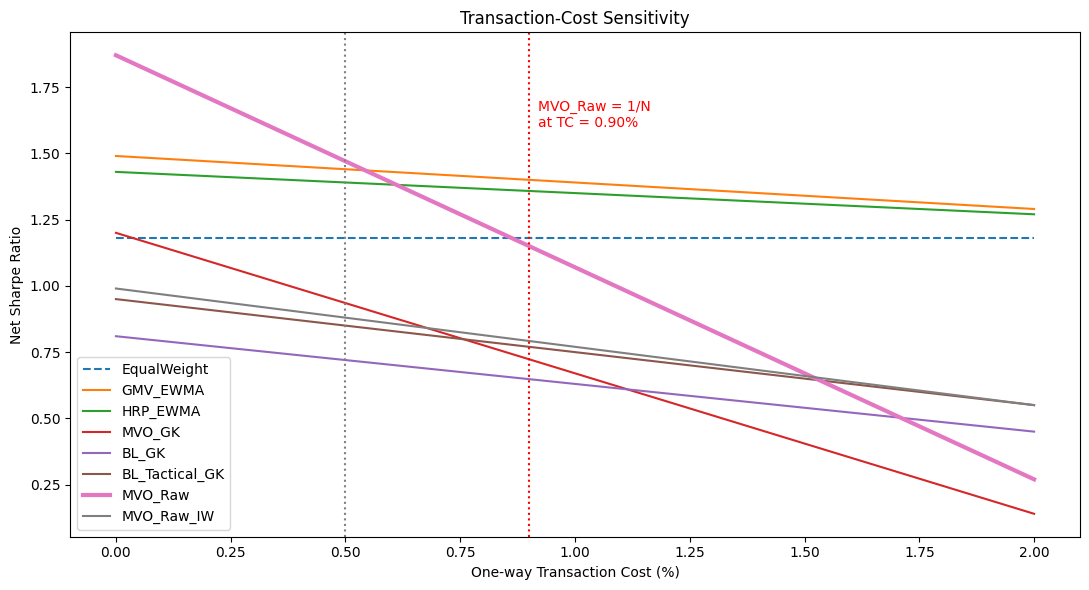

In [6]:
# ============================================================
# FIGURE 5.9 — Transaction Cost Sensitivity
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

tc = np.linspace(0, 2.0, 100)

equalweight = np.ones_like(tc) * 1.18
gmv = 1.49 - 0.10*tc
hrp = 1.43 - 0.08*tc
mvo_gk = 1.20 - 0.53*tc
bl_gk = 0.81 - 0.18*tc
bl_tactical = 0.95 - 0.20*tc
mvo_raw = 1.87 - 0.80*tc
mvo_raw_iw = 0.99 - 0.22*tc

plt.figure(figsize=(11,6))

plt.plot(tc, equalweight, linestyle='--', label='EqualWeight')
plt.plot(tc, gmv, label='GMV_EWMA')
plt.plot(tc, hrp, label='HRP_EWMA')
plt.plot(tc, mvo_gk, label='MVO_GK')
plt.plot(tc, bl_gk, label='BL_GK')
plt.plot(tc, bl_tactical, label='BL_Tactical_GK')
plt.plot(tc, mvo_raw, linewidth=3, label='MVO_Raw')
plt.plot(tc, mvo_raw_iw, label='MVO_Raw_IW')

plt.axvline(0.5, linestyle=':', color='gray')
plt.axvline(0.9, linestyle=':', color='red')

plt.text(0.92, 1.6, "MVO_Raw = 1/N\nat TC = 0.90%", color='red')

plt.xlabel("One-way Transaction Cost (%)")
plt.ylabel("Net Sharpe Ratio")
plt.title("Transaction-Cost Sensitivity")
plt.legend()

plt.tight_layout()
plt.show()

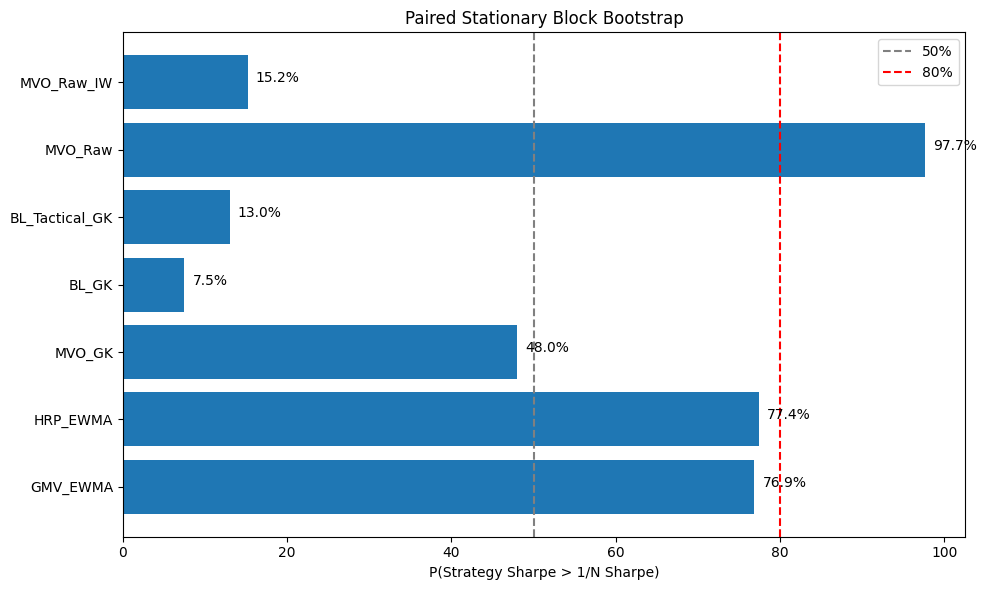

In [8]:
# ============================================================
# FIGURE 5.10 — Bootstrap Outperformance Probability
# ============================================================

import matplotlib.pyplot as plt

strategies = [
    "GMV_EWMA",
    "HRP_EWMA",
    "MVO_GK",
    "BL_GK",
    "BL_Tactical_GK",
    "MVO_Raw",
    "MVO_Raw_IW"
]

prob = [76.9, 77.4, 48.0, 7.5, 13.0, 97.7, 15.2]

plt.figure(figsize=(10,6))

bars = plt.barh(strategies, prob)

plt.axvline(50, linestyle='--', color='gray', label='50%')
plt.axvline(80, linestyle='--', color='red', label='80%')

for i, v in enumerate(prob):
    plt.text(v + 1, i, f"{v:.1f}%")

plt.xlabel("P(Strategy Sharpe > 1/N Sharpe)")
plt.title("Paired Stationary Block Bootstrap")
plt.legend()

plt.tight_layout()
plt.show()

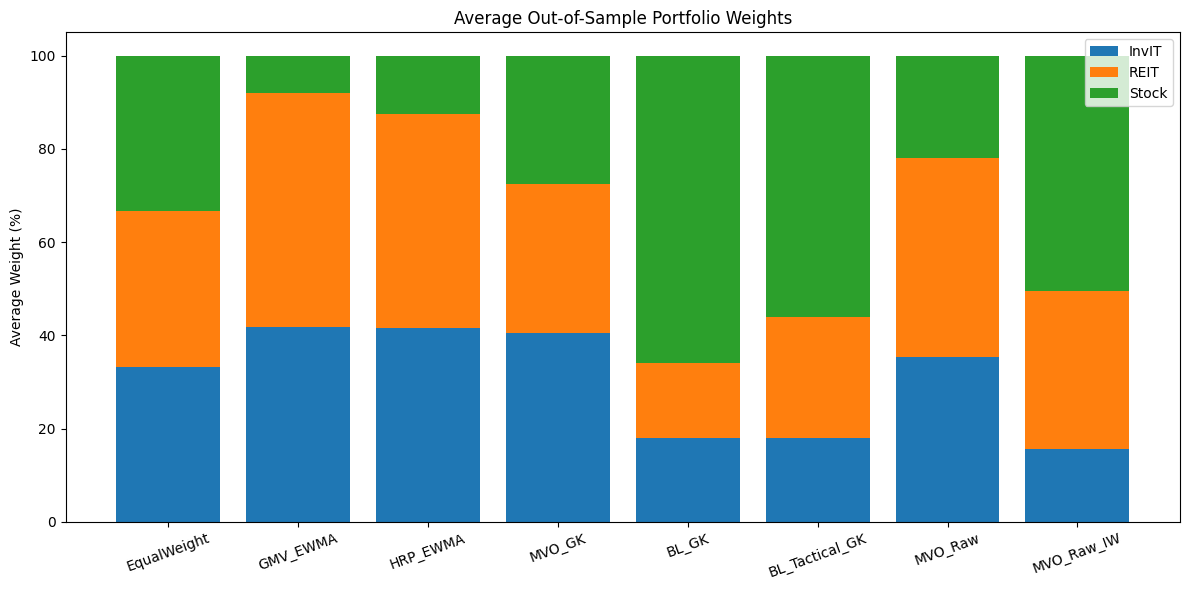

In [9]:
# ============================================================
# FIGURE 5.11 — Average Portfolio Weights
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

strategies = [
    "EqualWeight",
    "GMV_EWMA",
    "HRP_EWMA",
    "MVO_GK",
    "BL_GK",
    "BL_Tactical_GK",
    "MVO_Raw",
    "MVO_Raw_IW"
]

invit = [33.3, 41.7, 41.5, 40.5, 18.0, 18.0, 35.4, 15.5]
reit  = [33.3, 50.3, 46.0, 32.0, 16.0, 26.0, 42.7, 34.0]
stock = [33.4, 8.0, 12.5, 27.5, 66.0, 56.0, 21.9, 50.5]

x = np.arange(len(strategies))

plt.figure(figsize=(12,6))

plt.bar(x, invit, label='InvIT')
plt.bar(x, reit, bottom=invit, label='REIT')

bottom2 = np.array(invit) + np.array(reit)

plt.bar(x, stock, bottom=bottom2, label='Stock')

plt.xticks(x, strategies, rotation=20)
plt.ylabel("Average Weight (%)")
plt.title("Average Out-of-Sample Portfolio Weights")
plt.legend()

plt.tight_layout()
plt.show()